In [95]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


# Multishank sessions only
multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41,42,43,44],
    25: [16,17,18,25,26],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

multishank_mouse_days = {
    27: [23,24,26],
    25: [24, 25],
    26: [19],
    28: [23],    
}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np

def make_annotations(mouse, path=None):
    Mouse = f'M{mouse}'

    data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
    shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
    clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
    clusters_df = clusters_df[clusters_df['mouse'] == mouse]
    shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
    clusters_df = reconstruct_shank_id(clusters_df, mouse)
    probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
    adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)
    
    ymin = -300; ymax = 3000
    xmin = -200; xmax = 1000
    xs = np.arange(xmin, xmax, 1)
    ys = np.arange(ymin, ymax, 1)

    if os.path.exists(f"{path}/M{mouse}_annotations.npy"):
        # Load annotations and colors from disk
        annotations = np.load(f"{path}/M{mouse}_annotations.npy", allow_pickle=True)
        annotation_colors = np.load(f"{path}/M{mouse}_annotation_colors.npy", allow_pickle=True)
        return annotations, annotation_colors, xs, ys
    
    else:
        annotations = np.zeros((len(ys), len(xs)), dtype=object)
        for yi, y in enumerate(ys):
            for xi, x in enumerate(xs):
                coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
                z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
                annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
                if len(structure_set[structure_set['id'] == annotation_index]) ==1:
                    annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
                else:
                    annotation ='root' # out of brain
                annotations[yi,xi] = annotation

        annotation_colors = get_annotation_colors_2D(annotations)

        # Save
        np.save(f"{path}/M{mouse}_annotations.npy", annotations)
        np.save(f"{path}/M{mouse}_annotation_colors.npy", annotation_colors)

    return annotations, annotation_colors, xs, ys

In [3]:
def plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all_cells, path='/Users/harryclark/Documents/spatial-manifolds/data'):
    """
    Plot GCS and NGS cells on the annotated probe map for a given mouse and day.
    GCS cells are shown in red, NGS cells in blue, all other cells in gray.
    """
    print(f'printing probe map for Mouse {mouse} Day {day} with {len(gcs)} GCS cells, {len(ngs)} NGS cells, and {len(all_cells)} total cells')
    # Load annotations and colors
    annotations, annotation_colors, xs, ys = make_annotations(mouse, path=path)
    unique_colors = np.unique(annotation_colors)
    
    fig, ax = plt.subplots(figsize=(6, 10))
    # Plot annotation background
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax.scatter(x_points, y_points, color=color_, s=1, rasterized=True)
    plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa',
                   probe_alpha=0.5, contacts_alpha=0.5, probe_color='grey', probe_edgecolor='black')
    
    # Plot all cells in gray
    ax.scatter(all_cells.probe_x.values, all_cells.probe_y.values, marker='o', color="grey", alpha=0.3, s=10, label='All')
    if len(ngs) > 0:
        ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color='#3171ae', alpha=0.7, s=30, label='NGS')
    if len(gcs) > 0:
        ax.scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color='#c04744', alpha=0.7, s=30, label='GCS')
    
    ax.set_ylim([0, 3000])
    ax.set_xlim([-100, 900])
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M{mouse}D{day}_probe_map.pdf')
    plt.close()

'''
for mouse, days in multishank_mouse_days.items():
    for day in days:
        gcs, ngs, all = classify_cells_both_sessions(mouse=mouse, day=day, percentile_threshold=95, verbose=False)
        plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all)
'''



'\nfor mouse, days in multishank_mouse_days.items():\n    for day in days:\n        gcs, ngs, all = 
classify_cells_both_sessions(mouse=mouse, day=day, percentile_threshold=95, verbose=False)\n        
plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all)\n'

In [4]:
import numpy as np

def make_hit_mask(beh, trial_types):
    """
    Build a boolean mask over trials marking hits for specific trial types.

    Parameters
    ----------
    beh : dict-like
        Behaviour output from compute_vr_tcs; expects beh['trials']
        with at least columns 'type' and 'hit'.
    trial_types : str, int, or list/tuple of these
        Trial type(s) to include (e.g. 'b', 'nb', or ['b', 'nb']).

    Returns
    -------
    mask : np.ndarray of bool, shape (n_trials,)
        True where trial is one of the requested types AND hit == 1,
        False otherwise.
    """
    trials = beh['trials']

    # Normalise trial_types to a list
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]

    # Mask for requested types
    type_mask = trials['type'].isin(trial_types)

    # Mask for hits (assuming 1 = hit)
    hit_mask = trials['performance'] == 'hit'

    # Combined mask; length == number of rows in beh['trials']
    mask = (type_mask & hit_mask).to_numpy()

    return mask

def make_trialtype_mask(beh, trial_types):
    """
    Boolean mask over trials marking where the trial type is in trial_types,
    regardless of performance (hit/miss/etc.).
    """
    trials = beh['trials']

    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]

    type_mask = trials['type'].isin(trial_types)
    return type_mask.to_numpy()


Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


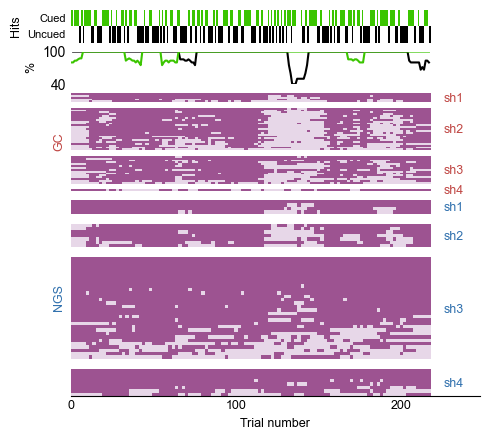

Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


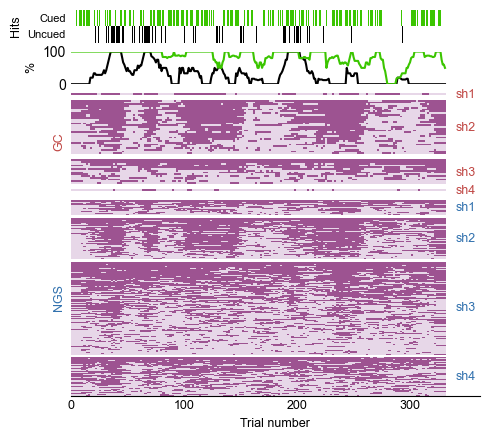

In [5]:
ngs_color = "#3171ae"  # NGS color for shank text
gc_color = "#c04744"   # GC color for shank text

multishank_mouse_days = {
    27: [23,26],
    25: [24,25],
    26: [19],
    28: [23],    
}

multishank_mouse_days = {
    25: [25],
    26: [19], 
}

# --- Raster plot of task_anchored_labels for all cells, ordered by shank,
#     with rolling hit rate on top, HIT row below, then GCS and NGS rasters ---
for mouse, days in multishank_mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        
        gcs, ngs, all = classify_cells_both_sessions(
            mouse=mouse, day=day, percentile_threshold=95, verbose=False
        )
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False
        )
        last_ephys_time_bin = clusters[clusters.index[0]].count(
            bin_size=time_bs, time_units='ms'
        ).index[-1]
        print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all)} total cells')

        # Compute GCS task-anchored label rasters (ordered as in gcs DataFrame)
        gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
        gc_shank_ids = sorted(gcs['shank_id'].unique())
        gcs_cells_by_shank = {
            shank: gcs[gcs['shank_id'] == shank].cluster_id.values
            for shank in gc_shank_ids
        }
        gcs_labels = []
        gcs_rate_maps = []
        gcs_shank_order = []
        for shank in gc_shank_ids:
            for cluster_id in gcs_cells_by_shank[shank]:
                try:
                    tc = tcs[cluster_id] if cluster_id in tcs else None
                    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                    tc = tc[:last_ephys_bin]
                    tcs_to_use = {cluster_id: tc}
                    tcs_to_use[1000] = tc

                    results = spectral_analysis(tcs_to_use, tl, bs=bs)
                    spectrograms = results[3]
                    fvalid = results[5]
                    S = spectrograms.mean(0)
                    max_peaks = np.argmax(S, axis=0)
                    labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                    labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                    gcs_labels.append(labels)
                    gcs_rate_maps.append(tc)
                    gcs_shank_order.append(shank)
                except Exception as e:
                    print(f"Error processing GCS cluster {cluster_id}: {e}")

        # Sort GCS by shank, then by task-anchored sum descending within shank
        gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels])
        gcs_shank_arr = np.array(gcs_shank_order)
        gc_order = []
        for shank in gc_shank_ids:
            shank_indices = np.where(gcs_shank_arr == shank)[0]
            sorted_shank = shank_indices[np.argsort(-gcs_label_sums[shank_indices])]
            gc_order.extend(sorted_shank.tolist())
        gcs_labels = [gcs_labels[i] for i in gc_order]
        gcs_rate_maps = [gcs_rate_maps[i] for i in gc_order]
        gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

        # Group NGS cells by shank
        ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
        shank_ids = sorted(ngs['shank_id'].unique())
        ngs_cells_by_shank = {
            shank: ngs[ngs['shank_id'] == shank].cluster_id.values
            for shank in shank_ids
        }

        # Flatten all cells, keeping shank info
        global_cell_list = []
        global_shank_list = []
        for shank in shank_ids:
            for cid in ngs_cells_by_shank[shank]:
                global_cell_list.append(cid)
                global_shank_list.append(shank)

        # Compute NGS task-anchored label rasters, ordered by shank
        avg_rate_maps = []
        all_labels = []
        cell_ids_ordered = []
        cell_shank_order = []

        for idx, (target_cluster_id, shank) in enumerate(
            zip(global_cell_list, global_shank_list)
        ):
            try:
                tcs_to_use = {
                    cluster_id: tcs[cluster_id]
                    for cluster_id in [target_cluster_id]
                    if cluster_id in tcs
                }
                tcs_to_use[1000] = tcs_to_use[target_cluster_id]

                tc = tcs[target_cluster_id]
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]

                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3]
                fvalid = results[5]
                S = spectrograms.mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
            
            except Exception as e:
                print(f"Error processing cluster {target_cluster_id} on shank {shank}: {e}")
                labels = np.full_like(labels, np.nan)

            avg_rate_maps.append(tc)
            cell_shank_order.append(shank)
            all_labels.append(labels)
            cell_ids_ordered.append(target_cluster_id)

        # Sort within each shank by task-anchored sum descending
        shank_arr = np.array(cell_shank_order)
        label_sums = np.array([np.nansum(lab == 1) for lab in all_labels])
        order = []
        for shank in shank_ids:
            shank_indices = np.where(shank_arr == shank)[0]
            sorted_shank = shank_indices[np.argsort(-label_sums[shank_indices])]
            order.extend(sorted_shank.tolist())
        order = np.array(order)

        # Pad both GCS and NGS label matrices to the same number of columns
        max_len = max(
            [len(lab) for lab in all_labels] + [len(lab) for lab in gcs_labels]
        )

        # --- Build GCS raster with 3 blank rows between shanks ---
        gc_blocks = []
        for shank in gc_shank_ids:
            block = [gcs_labels[i] for i in range(len(gcs_labels)) if gcs_shank_order[i] == shank]
            block_matrix = np.full((len(block), max_len), np.nan)
            for i, lab in enumerate(block):
                block_matrix[i, :len(lab)] = lab
            gc_blocks.append(block_matrix)
        labels_matrix_gcs = gc_blocks[0]
        for block in gc_blocks[1:]:
            blank = np.full((3, max_len), np.nan)
            labels_matrix_gcs = np.vstack([labels_matrix_gcs, blank, block])

        # --- Build NGS raster with 3 blank rows between shanks ---
        ngs_blocks = []
        for shank in shank_ids:
            block = [all_labels[idx] for idx in order if cell_shank_order[order[idx]] == shank]
            block_matrix = np.full((len(block), max_len), np.nan)
            for i, lab in enumerate(block):
                block_matrix[i, :len(lab)] = lab
            ngs_blocks.append(block_matrix)
        labels_matrix_ngs = ngs_blocks[0]
        for block in ngs_blocks[1:]:
            blank = np.full((3, max_len), np.nan)
            labels_matrix_ngs = np.vstack([labels_matrix_ngs, blank, block])

        # ------------------------------------------------------------------
        # Build a 2×max_len raster for HIT TRIALS using make_hit_mask:
        # Row 0: cued (B) hits, Row 1: uncued (NB) hits
        # ------------------------------------------------------------------
        nb_hit_mask = make_hit_mask(beh, 'nb')
        b_hit_mask  = make_hit_mask(beh, 'b')
        n_trials = len(nb_hit_mask)
        n_use = min(max_len, n_trials)
        hit_raster = np.full((2, max_len), np.nan)
        # Row 0: B hits (cued)
        hit_raster[0, :n_use][b_hit_mask[:n_use]] = 1
        # Row 1: NB hits (uncued)
        hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1

        # Custom colormap: 0=white, 1=green (cued), 2=black (uncued)
        from matplotlib.colors import ListedColormap, BoundaryNorm
        hit_cmap = ListedColormap(["white", "#3bc500", "black"])
        hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)

        # For imshow, set cued hits to 1, uncued hits to 2
        hit_raster_plot = np.zeros_like(hit_raster)
        hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
        hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

        # ------------------------------------------------------------------
        # Rolling average of hit rate for NB and B trials
        # ------------------------------------------------------------------
        window = 10
        kernel = np.ones(window) / window

        nb_type_mask = make_trialtype_mask(beh, 'nb')
        b_type_mask  = make_trialtype_mask(beh, 'b')
        nb_hits   = nb_hit_mask.astype(float)
        b_hits    = b_hit_mask.astype(float)
        nb_trials = nb_type_mask.astype(float)
        b_trials  = b_type_mask.astype(float)

        nb_num = np.convolve(nb_hits,   kernel, mode='same')
        nb_den = np.convolve(nb_trials, kernel, mode='same')
        b_num  = np.convolve(b_hits,    kernel, mode='same')
        b_den  = np.convolve(b_trials,  kernel, mode='same')

        nb_rolling = np.full_like(nb_num, np.nan, dtype=float)*100
        b_rolling  = np.full_like(b_num,  np.nan, dtype=float)*100
        nb_rolling[nb_den > 0] = nb_num[nb_den > 0] / nb_den[nb_den > 0] * 100
        b_rolling[b_den > 0]   = b_num[b_den > 0]   / b_den[b_den > 0] * 100

        nb_rolling_full = np.full(max_len, np.nan)
        b_rolling_full  = np.full(max_len, np.nan)
        nb_rolling_full[:n_use] = nb_rolling[:n_use]
        b_rolling_full[:n_use]  = b_rolling[:n_use]

        cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

        fig, axes = plt.subplots(
            4, 1, figsize=(5, 4.5), sharex=True,
            gridspec_kw={'height_ratios': [1, 1, 3, 6]}
        )

        axes[0].imshow(hit_raster_plot, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                       interpolation='nearest', rasterized=False)
        axes[0].set_yticks([0, 1])
        axes[0].set_yticklabels(['Cued', 'Uncued'], fontsize=8)
        axes[0].set_ylabel('Hits', fontsize=9)
        for spine in axes[0].spines.values(): spine.set_visible(False)
        axes[0].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False, length=0)

        axes[1].plot(nb_rolling_full, color='black', label='NB hit rate')
        axes[1].plot(b_rolling_full,  color='#3bc500', label='B hit rate')
        axes[1].set_ylabel('%', fontsize=9)

        y_vals = np.concatenate([nb_rolling_full, b_rolling_full])
        finite = np.isfinite(y_vals)
        if finite.any():
            y_min, y_max = y_vals[finite].min(), y_vals[finite].max()
            if y_min == y_max:
                margin = 0.05 * (abs(y_min) if y_min != 0 else 1.0)
                y_min -= margin; y_max += margin
        else:
            y_min, y_max = 0.0, 100
        axes[1].set_ylim(y_min, y_max)
        axes[1].set_yticks(np.linspace(y_min, y_max, 2))
        for spine in axes[1].spines.values(): spine.set_visible(False)
        axes[1].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False, length=0)

        axes[2].imshow(labels_matrix_gcs, aspect='auto', cmap=cmap, norm=norm,
                       interpolation='nearest', rasterized=False)
        axes[2].set_ylabel('GC', fontsize=9, color=gc_color)
        axes[2].set_yticks([])
        for spine in axes[2].spines.values(): spine.set_visible(False)
        axes[2].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False, length=0)

        # Add shank text ("sh1", "sh2", ...) at vertical midpoint of each GC shank block, in gc_color
        y_gc = 0
        for i, (block, shank) in enumerate(zip(gc_blocks, gc_shank_ids)):
            block_height = block.shape[0]
            y_mid = y_gc + block_height / 2
            axes[2].text(
                labels_matrix_gcs.shape[1] + 8, y_mid, f"sh{shank + 1}",
                fontsize=9, va='center', ha='left', color=gc_color, clip_on=False
            )
            y_gc += block_height + 3  # move past block and blank

        axes[3].imshow(labels_matrix_ngs, aspect='auto', cmap=cmap, norm=norm,
                       interpolation='nearest', rasterized=False)
        axes[3].set_xlabel('Trial number', fontsize=9)
        axes[3].set_ylabel('NGS', fontsize=9, color=ngs_color)
        axes[3].set_yticks([])
        for spine in axes[3].spines.values(): spine.set_visible(False)
        axes[3].tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

        # Add shank text ("sh1", "sh2", ...) at vertical midpoint of each NGS shank block, in ngs_color
        y = 0
        for i, (block, shank) in enumerate(zip(ngs_blocks, shank_ids)):
            block_height = block.shape[0]
            y_mid = y + block_height / 2
            axes[3].text(
                labels_matrix_ngs.shape[1] + 8, y_mid, f"sh{shank + 1}",
                fontsize=9, va='center', ha='left', color=ngs_color, clip_on=False
            )
            y += block_height + 3  # move past block and blank

        axes[2].set_xlim([-0.5, labels_matrix_gcs.shape[1] + 30])
        axes[3].set_xlim([-0.5, labels_matrix_ngs.shape[1] + 30])
        axes[2].spines["bottom"].set_visible(True)
        axes[3].spines["bottom"].set_visible(True)
        xticks = list(range(0, max_len + 1, 100))
        axes[2].set_xticks(xticks)
        axes[2].set_xticklabels(xticks, fontsize=9)
        axes[3].set_xticks(xticks)
        axes[3].set_xticklabels(xticks, fontsize=9)
        axes[2].spines["bottom"].set_visible(False)
        plt.tight_layout()
        plt.subplots_adjust(hspace=0.1)
        plt.savefig(
            f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            f'figure_6_task_anchoring/M{mouse}D{day}_TA_raster_with_hits.pdf',
            dpi=1000
        )
        plt.show()

Processing M25D24...
Processing M25D23...
Processing M25D25...


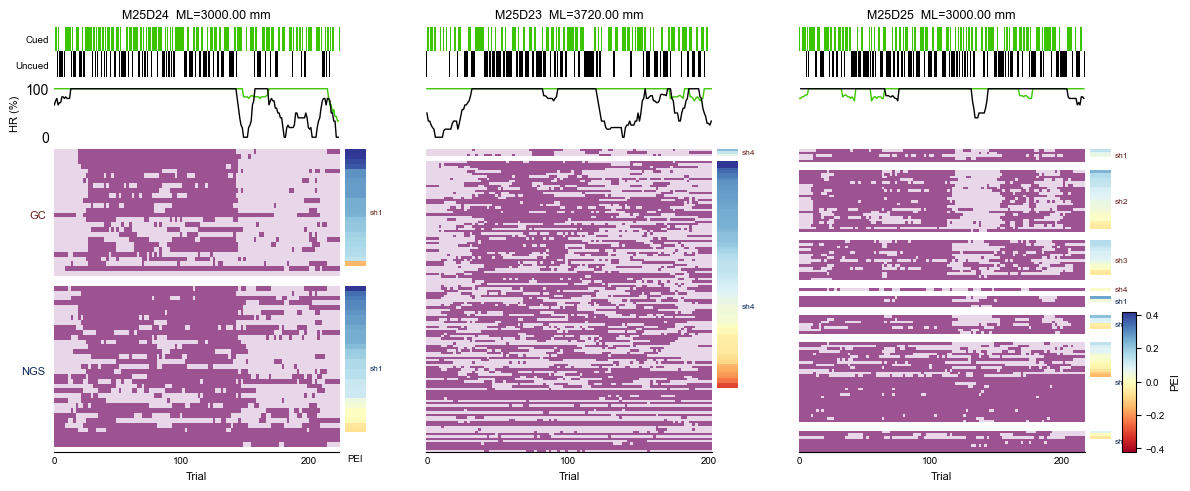

In [6]:
# ── 3-session summary: trial-type raster / % hits / anchoring raster / PEI ────
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as mgridspec

sessions = [(27, 26), (25, 24), (27, 23), (25, 25)]
sessions = [(25, 24), (25, 23), (25, 25)]

hit_cmap = ListedColormap(["white", "#3bc500", "black"])
hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
cmap_ta  = ListedColormap(["#e7d7e8", "#9d5391", "white"])
norm_ta  = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap_ta.N)
pei_cmap = plt.cm.RdYlBu

MIN_TRIALS = 10   # minimum anchored AND non-anchored trials required per condition

# ── PEI helper: dhr_uncued - dhr_cued ────────────────────────────────────────
def compute_cell_pei(labels, b_hit_mask, nb_hit_mask, b_type_mask, nb_type_mask):
    """Returns PEI = Δhit_rate(uncued) − Δhit_rate(cued) for one cell.
    Returns NaN if either anchored or non-anchored trials number < MIN_TRIALS
    in either condition."""
    n = len(labels)
    valid     = ~np.isnan(labels.astype(float))
    anchored  = valid & (labels == 1)
    nanchored = valid & (labels == 0)

    def _dhr(hit_mask, type_mask):
        h   = hit_mask[:n].astype(float)
        t   = type_mask[:n]
        a_t = anchored  & t
        n_t = nanchored & t
        if a_t.sum() < MIN_TRIALS or n_t.sum() < MIN_TRIALS:
            return np.nan
        return float(h[a_t].mean() - h[n_t].mean())

    dhr_u = _dhr(nb_hit_mask, nb_type_mask)
    dhr_c = _dhr(b_hit_mask,  b_type_mask)
    if np.isnan(dhr_u) or np.isnan(dhr_c):
        return np.nan
    return dhr_u - dhr_c

# ── Collect data for each session ─────────────────────────────────────────────
session_data = []
for mouse, day in sessions:
    print(f"Processing M{mouse}D{day}...")
    gcs, ngs, _ = classify_cells_both_sessions(mouse=mouse, day=day, percentile_threshold=95, verbose=False)
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    max_len = int(last_ephys_bin / (tl / bs))

    # ── ML location from locations DataFrame ──────────────────────────────
    loc_subset = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    ml_loc = float(loc_subset['coord_SCs_x'].iloc[0]) if len(loc_subset) > 0 else np.nan

    # Pre-compute hit / type masks (reused for PEI and rolling hit rate)
    nb_hit_mask_full  = make_hit_mask(beh, 'nb')
    b_hit_mask_full   = make_hit_mask(beh, 'b')
    nb_type_mask_full = make_trialtype_mask(beh, 'nb')
    b_type_mask_full  = make_trialtype_mask(beh,  'b')

    # ── GC: compute labels + PEI, sort by PEI (desc) within shank ─────────
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gc_shank_ids = sorted(gcs['shank_id'].unique())
    gcs_labels_list, gcs_shank_order, gcs_pei_list = [], [], []
    for shank in gc_shank_ids:
        for cid in gcs[gcs['shank_id'] == shank].cluster_id.values:
            try:
                tc = gaussian_filter(np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
                results = spectral_analysis({cid: tc, 1000: tc}, tl, bs=bs)
                S = results[3].mean(0)
                labels_idx = np.isin(np.argmax(S, axis=0), [12, 28, 44, 60, 76]).astype(int)
                labels  = get_kmeans_spatial_labels(tc, labels_idx, bs=bs, tl=tl)
                pei_val = compute_cell_pei(labels, b_hit_mask_full, nb_hit_mask_full,
                                           b_type_mask_full, nb_type_mask_full)
                gcs_labels_list.append(labels)
                gcs_shank_order.append(shank)
                gcs_pei_list.append(pei_val)
            except Exception:
                pass
    gcs_shank_arr = np.array(gcs_shank_order)
    gcs_pei_arr   = np.array(gcs_pei_list, dtype=float)
    gc_order = []
    for shank in gc_shank_ids:
        idx      = np.where(gcs_shank_arr == shank)[0]
        sort_key = np.where(np.isnan(gcs_pei_arr[idx]), -np.inf, gcs_pei_arr[idx])
        gc_order.extend(idx[np.argsort(-sort_key)].tolist())
    gcs_labels_list = [gcs_labels_list[i] for i in gc_order]
    gcs_shank_order = [gcs_shank_order[i] for i in gc_order]
    gcs_pei_list    = [gcs_pei_list[i]    for i in gc_order]

    # ── NGS: compute labels + PEI, sort by PEI (desc) within shank ────────
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    shank_ids = sorted(ngs['shank_id'].unique())
    all_labels_list, cell_shank_order, ngs_pei_list = [], [], []
    global_cells = [(cid, sh) for sh in shank_ids for cid in ngs[ngs['shank_id'] == sh].cluster_id.values]
    for cid, shank in global_cells:
        try:
            tc = gaussian_filter(np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
            results = spectral_analysis({cid: tc, 1000: tc}, tl, bs=bs)
            S = results[3].mean(0)
            labels_idx = np.isin(np.argmax(S, axis=0), [12, 28, 44, 60, 76]).astype(int)
            labels  = get_kmeans_spatial_labels(tc, labels_idx, bs=bs, tl=tl)
            pei_val = compute_cell_pei(labels, b_hit_mask_full, nb_hit_mask_full,
                                       b_type_mask_full, nb_type_mask_full)
        except Exception:
            labels  = np.full(max_len, np.nan)
            pei_val = np.nan
        all_labels_list.append(labels)
        cell_shank_order.append(shank)
        ngs_pei_list.append(pei_val)
    shank_arr   = np.array(cell_shank_order)
    ngs_pei_arr = np.array(ngs_pei_list, dtype=float)
    ngs_order   = []
    for shank in shank_ids:
        idx      = np.where(shank_arr == shank)[0]
        sort_key = np.where(np.isnan(ngs_pei_arr[idx]), -np.inf, ngs_pei_arr[idx])
        ngs_order.extend(idx[np.argsort(-sort_key)].tolist())
    all_labels_list  = [all_labels_list[i]  for i in ngs_order]
    cell_shank_order = [cell_shank_order[i] for i in ngs_order]
    ngs_pei_list     = [ngs_pei_list[i]     for i in ngs_order]

    max_len = max([len(l) for l in all_labels_list] + [len(l) for l in gcs_labels_list])

    # ── Build raster matrices + flat per-cell PEI vectors ─────────────────
    def _build_matrix(labels_list, shank_order, shank_ids_list, pei_list):
        blocks, pei_blocks = [], []
        for shank in shank_ids_list:
            idxs  = [i for i, sh in enumerate(shank_order) if sh == shank]
            block = [labels_list[i] for i in idxs]
            peis  = [pei_list[i]    for i in idxs]
            bm    = np.full((len(block), max_len), np.nan)
            for k, lab in enumerate(block): bm[k, :len(lab)] = lab
            blocks.append(bm)
            pei_blocks.append(np.array(peis, dtype=float))
        mat     = blocks[0]
        pei_vec = pei_blocks[0]
        for blk, pb in zip(blocks[1:], pei_blocks[1:]):
            mat     = np.vstack([mat, np.full((3, max_len), np.nan), blk])
            pei_vec = np.concatenate([pei_vec, np.full(3, np.nan), pb])
        return mat, blocks, pei_vec

    labels_matrix_gcs, gc_blocks,  gc_pei_vec  = _build_matrix(gcs_labels_list, gcs_shank_order, gc_shank_ids, gcs_pei_list)
    labels_matrix_ngs, ngs_blocks, ngs_pei_vec = _build_matrix(all_labels_list,  cell_shank_order, shank_ids,   ngs_pei_list)

    n_gc_rows    = labels_matrix_gcs.shape[0]
    n_ngs_rows   = labels_matrix_ngs.shape[0]
    n_blank_rows = 1 if (n_gc_rows + n_ngs_rows < 20) else 2

    labels_combined = np.vstack([
        labels_matrix_gcs,
        np.full((n_blank_rows, max_len), np.nan),
        labels_matrix_ngs,
    ])
    pei_combined = np.concatenate([gc_pei_vec, np.full(n_blank_rows, np.nan), ngs_pei_vec])

    # ── Hit raster ────────────────────────────────────────────────────────
    n_use = min(max_len, len(nb_hit_mask_full))
    hit_raster = np.full((2, max_len), np.nan)
    hit_raster[0, :n_use][b_hit_mask_full[:n_use]]  = 1
    hit_raster[1, :n_use][nb_hit_mask_full[:n_use]] = 1
    hit_raster_plot = np.zeros_like(hit_raster)
    hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
    hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

    # ── Rolling hit rate ──────────────────────────────────────────────────
    window = 10
    kernel = np.ones(window) / window
    nb_type = nb_type_mask_full.astype(float)
    b_type  = b_type_mask_full.astype(float)
    nb_den  = np.convolve(nb_type, kernel, mode='same')
    b_den   = np.convolve(b_type,  kernel, mode='same')
    nb_r    = np.where(nb_den > 0, np.convolve(nb_hit_mask_full.astype(float), kernel, mode='same') / nb_den * 100, np.nan)
    b_r     = np.where(b_den  > 0, np.convolve(b_hit_mask_full.astype(float),  kernel, mode='same') / b_den  * 100, np.nan)
    nb_rolling = np.full(max_len, np.nan); nb_rolling[:n_use] = nb_r[:n_use]
    b_rolling  = np.full(max_len, np.nan); b_rolling[:n_use]  = b_r[:n_use]

    session_data.append(dict(
        mouse=mouse, day=day,
        ml_loc=ml_loc,
        labels_combined=labels_combined,
        pei_combined=pei_combined,
        gc_blocks=gc_blocks,  ngs_blocks=ngs_blocks,
        gc_shank_ids=gc_shank_ids, shank_ids=shank_ids,
        n_gc_rows=n_gc_rows,  n_blank_rows=n_blank_rows,
        hit_raster_plot=hit_raster_plot,
        nb_rolling=nb_rolling, b_rolling=b_rolling,
        max_len=max_len,
    ))

# ── Shared PEI colour scale across all sessions ────────────────────────────────
_all_pei = np.concatenate([sd['pei_combined'] for sd in session_data])
_fin_pei = _all_pei[np.isfinite(_all_pei)]
pei_vmax = float(np.nanpercentile(np.abs(_fin_pei), 99)) if len(_fin_pei) else 0.5
pei_vmax = max(pei_vmax, 1e-6)
try:
    pei_norm = TwoSlopeNorm(vcenter=0, vmin=-pei_vmax, vmax=pei_vmax)
except Exception:
    pei_norm = Normalize(vmin=-pei_vmax, vmax=pei_vmax)

# ── Figure layout ─────────────────────────────────────────────────────────────
n_ses      = len(sessions)
col_ratios = []
for s in range(n_ses):
    col_ratios.append(1.0)   # raster
    col_ratios.append(0.07)  # PEI strip
    if s < n_ses - 1:
        col_ratios.append(0.18)  # gap between sessions

fig = plt.figure(figsize=(3.5 * n_ses + 1.5, 5))
gs  = mgridspec.GridSpec(
    3, len(col_ratios),
    figure=fig,
    width_ratios=col_ratios,
    height_ratios=[1, 1, 6],
    hspace=0.08, wspace=0.04,
    left=0.07, right=0.95, top=0.92, bottom=0.07,
)

for col_i, sd in enumerate(session_data):
    ml          = sd['max_len']
    raster_col  = col_i * 3      # 0, 3, 6
    pei_col     = raster_col + 1 # 1, 4, 7
    n_comb_rows = sd['labels_combined'].shape[0]

    ax_hit  = fig.add_subplot(gs[0, raster_col])             # raster col only
    ax_pct  = fig.add_subplot(gs[1, raster_col], sharex=ax_hit)  # same width
    ax_anch = fig.add_subplot(gs[2, raster_col], sharex=ax_hit)
    ax_pei  = fig.add_subplot(gs[2, pei_col],    sharey=ax_anch)

    # ── Row 0: hit raster ─────────────────────────────────────────────────
    ax_hit.imshow(sd['hit_raster_plot'], aspect='auto', cmap=hit_cmap, norm=hit_norm,
                  interpolation='nearest', rasterized=True)
    ax_hit.set_yticks([0, 1])
    ax_hit.set_yticklabels(['Cued', 'Uncued'], fontsize=7) if col_i == 0 else ax_hit.set_yticklabels([])
    ml_str = f"{sd['ml_loc']:.2f}" if np.isfinite(sd['ml_loc']) else 'n/a'
    ax_hit.set_title(f"M{sd['mouse']}D{sd['day']}  ML={ml_str} mm", fontsize=9)
    for sp in ax_hit.spines.values(): sp.set_visible(False)
    ax_hit.tick_params(left=False, bottom=False, labelbottom=False, length=0)

    # ── Row 1: rolling hit rate ───────────────────────────────────────────
    x = np.arange(ml)
    ax_pct.plot(x, sd['b_rolling'],  color='#3bc500', linewidth=1.0)
    ax_pct.plot(x, sd['nb_rolling'], color='black',   linewidth=1.0)
    ax_pct.set_ylim(-2, 102)
    ax_pct.set_yticks([0, 100])
    if col_i == 0:
        ax_pct.set_ylabel('HR (%)', fontsize=8)
    else:
        ax_pct.set_yticklabels([])
    for sp in ax_pct.spines.values(): sp.set_visible(False)
    ax_pct.tick_params(left=False, bottom=False, labelbottom=False, length=0)

    # ── Row 2a: anchoring raster ──────────────────────────────────────────
    ax_anch.imshow(sd['labels_combined'], aspect='auto', cmap=cmap_ta, norm=norm_ta,
                   interpolation='nearest', rasterized=True)
    ax_anch.set_xlim(-0.5, ml - 0.5)
    ax_anch.set_yticks([])
    ax_anch.set_xlabel('Trial', fontsize=8)
    for sp in ax_anch.spines.values(): sp.set_visible(False)
    ax_anch.spines["bottom"].set_visible(True)
    ax_anch.tick_params(length=0)
    xticks = list(range(0, ml + 1, 100))
    ax_anch.set_xticks(xticks)
    ax_anch.set_xticklabels(xticks, fontsize=7)

    # GC / NGS group labels on the left (first column only)
    if col_i == 0:
        ngs_start = sd['n_gc_rows'] + sd['n_blank_rows']
        ax_anch.text(-ml * 0.03, sd['n_gc_rows'] / 2, 'GC',
                     fontsize=8, va='center', ha='right', color=gc_color_dark, clip_on=False)
        ax_anch.text(-ml * 0.03, ngs_start + (n_comb_rows - ngs_start) / 2, 'NGS',
                     fontsize=8, va='center', ha='right', color=ngs_color_dark, clip_on=False)

    # ── Row 2b: PEI strip ─────────────────────────────────────────────────
    ax_pei.imshow(sd['pei_combined'][:, np.newaxis], aspect='auto',
                  cmap=pei_cmap, norm=pei_norm,
                  interpolation='nearest', rasterized=True)
    ax_pei.set_xticks([])
    ax_pei.set_yticks([])
    for sp in ax_pei.spines.values(): sp.set_visible(False)
    if col_i == 0:
        ax_pei.set_xlabel('PEI', fontsize=7, labelpad=2)

    # Shank labels to the right of the PEI strip (axes-fraction coords)
    y_pos = 0
    for blk, shank in zip(sd['gc_blocks'], sd['gc_shank_ids']):
        y_frac = 1.0 - (y_pos + blk.shape[0] / 2) / n_comb_rows
        ax_pei.text(1.25, y_frac, f"sh{shank+1}",
                    transform=ax_pei.transAxes,
                    fontsize=6, va='center', ha='left', color=gc_color_dark, clip_on=False)
        y_pos += blk.shape[0] + 3
    y_pos = sd['n_gc_rows'] + sd['n_blank_rows']
    for blk, shank in zip(sd['ngs_blocks'], sd['shank_ids']):
        y_frac = 1.0 - (y_pos + blk.shape[0] / 2) / n_comb_rows
        ax_pei.text(1.25, y_frac, f"sh{shank+1}",
                    transform=ax_pei.transAxes,
                    fontsize=6, va='center', ha='left', color=ngs_color_dark, clip_on=False)
        y_pos += blk.shape[0] + 3

# ── PEI colourbar ─────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=pei_cmap, norm=pei_norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.96, 0.07, 0.012, 0.28])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('PEI', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/M25D24_M27D26_M27D23_TA_3col.pdf',
    dpi=300, bbox_inches='tight')

M25D24: 26 GC + 34 NGS = 60 cells


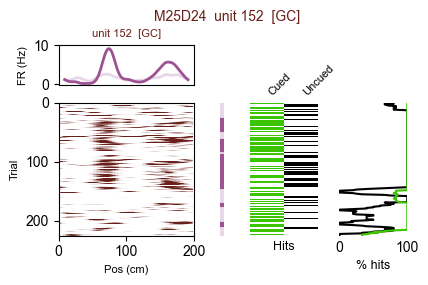

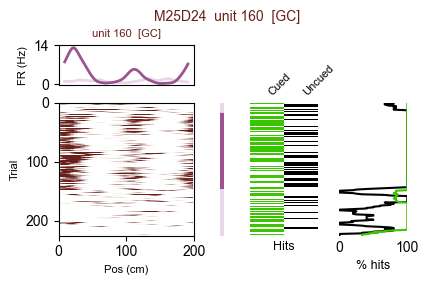

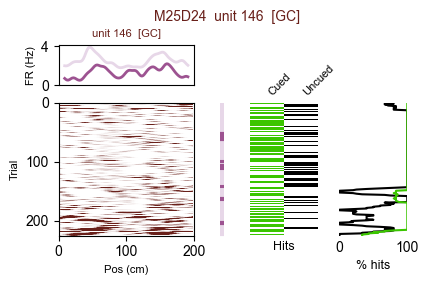

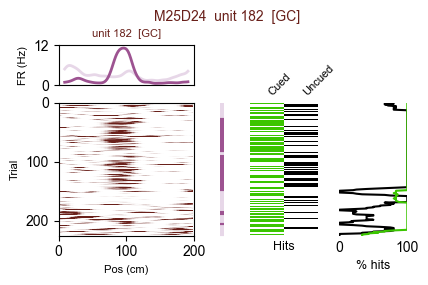

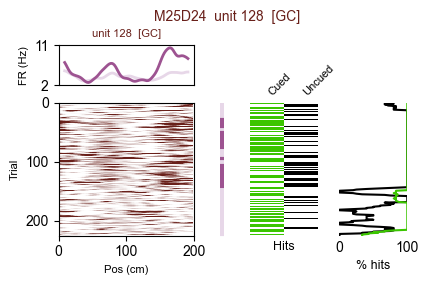

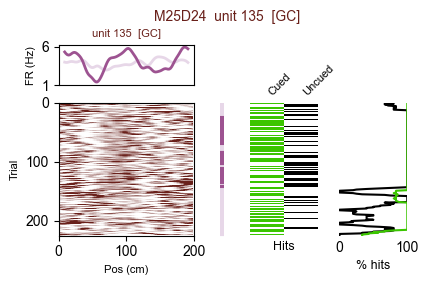

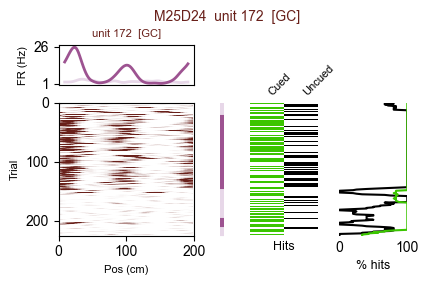

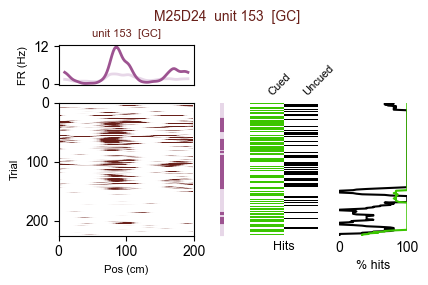

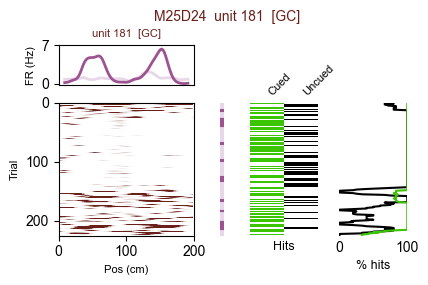

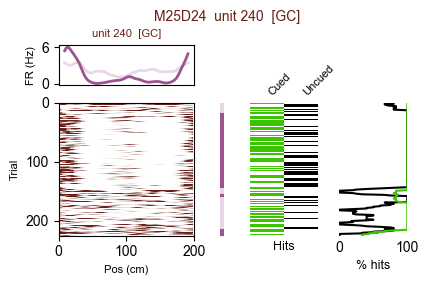

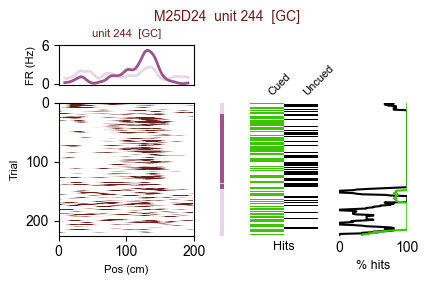

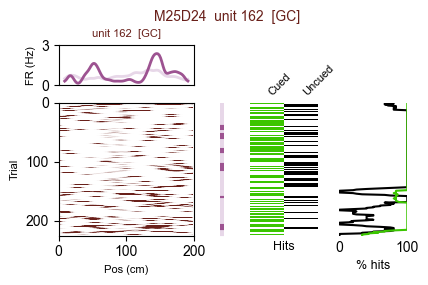

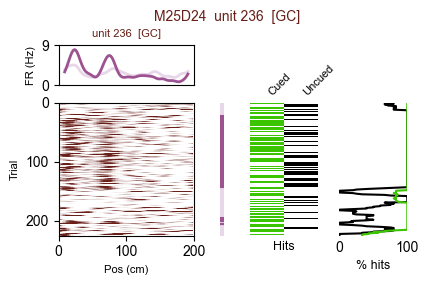

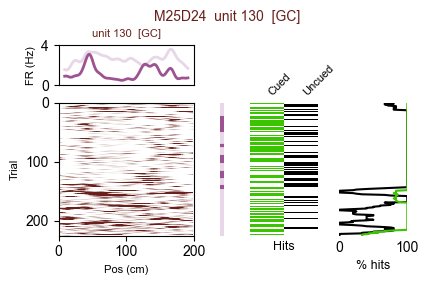

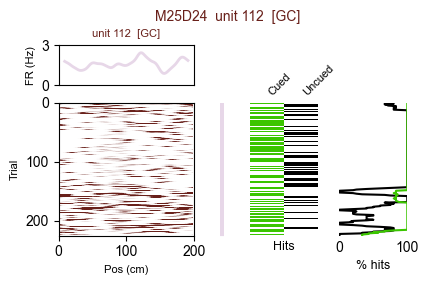

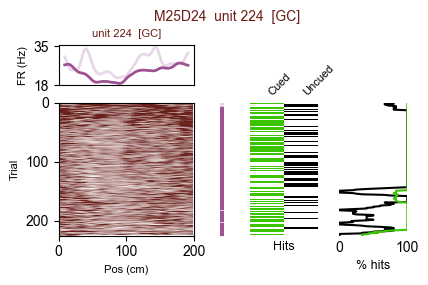

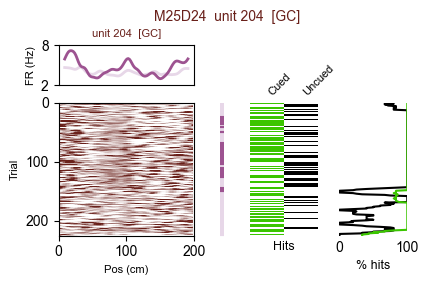

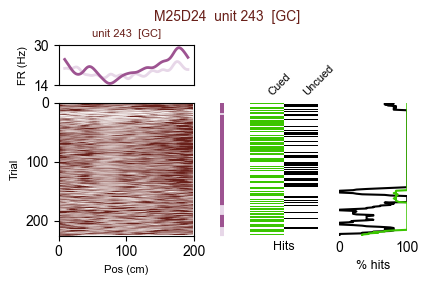

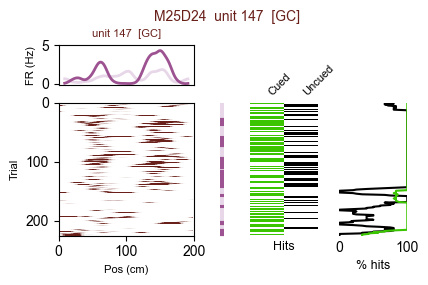

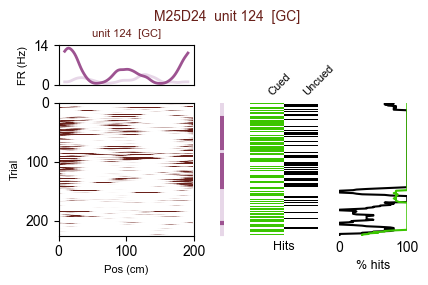

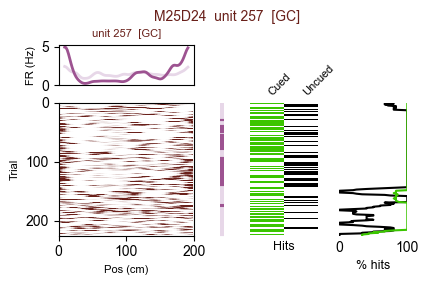

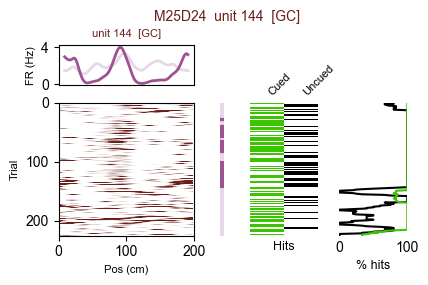

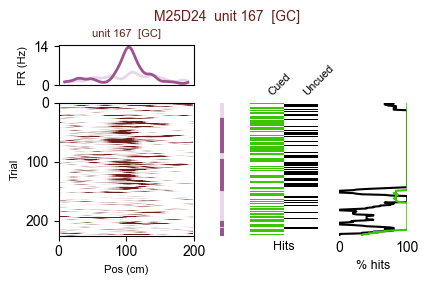

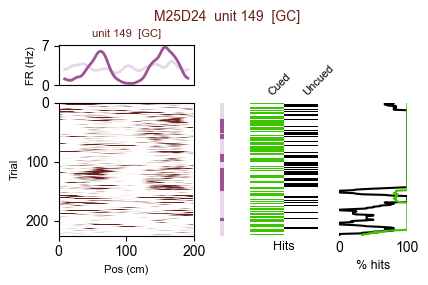

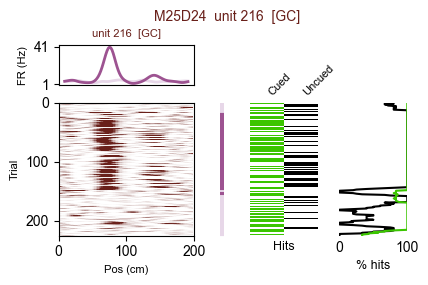

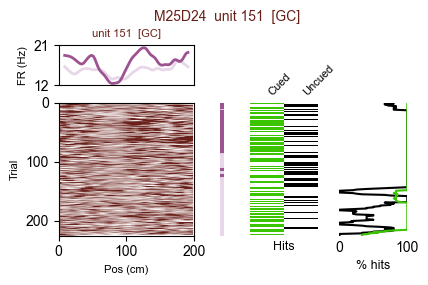

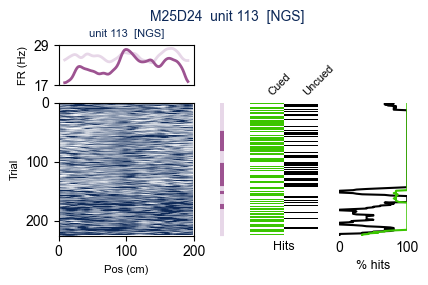

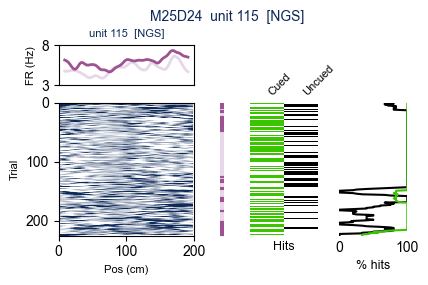

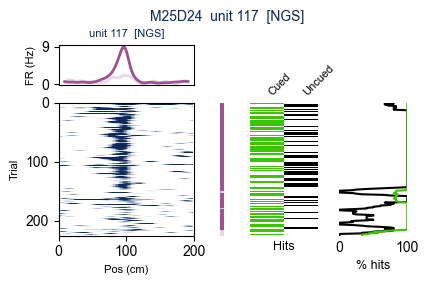

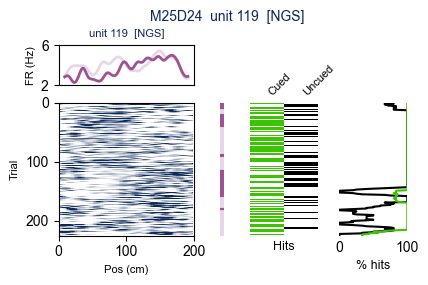

  ERROR unit 120 (NGS): all input arrays must have the same shape


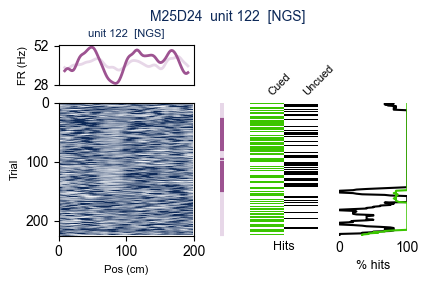

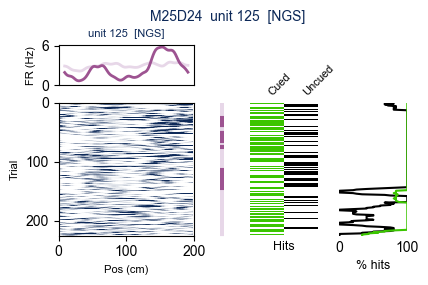

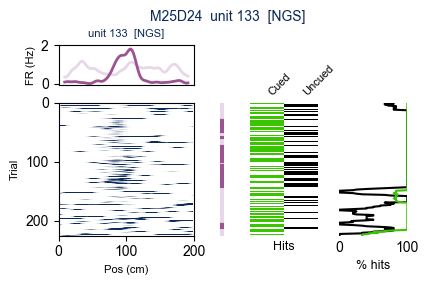

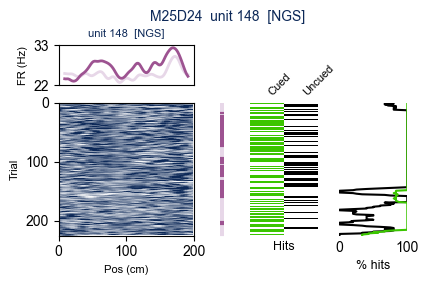

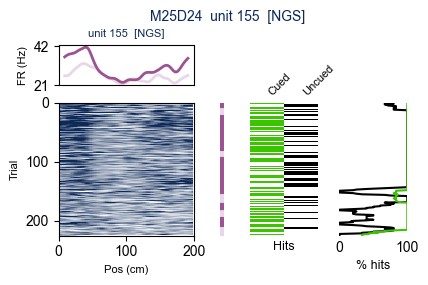

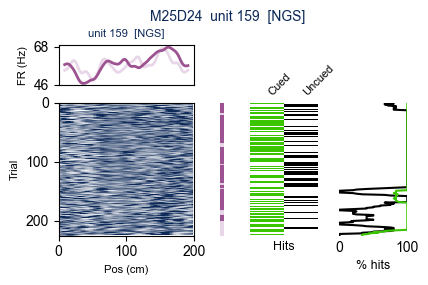

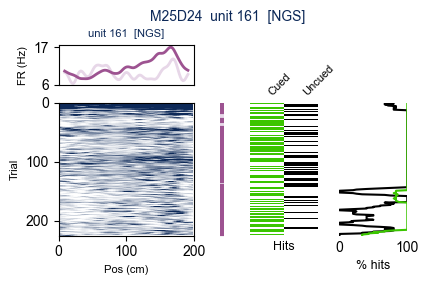

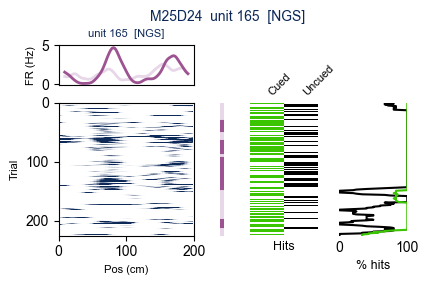

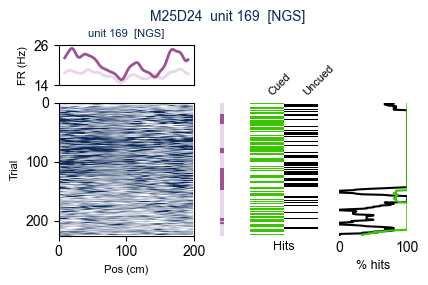

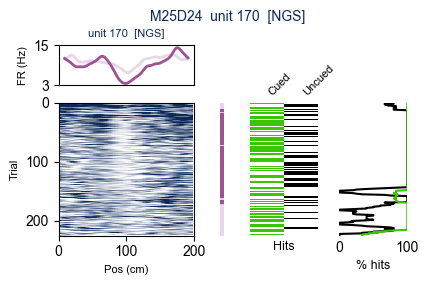

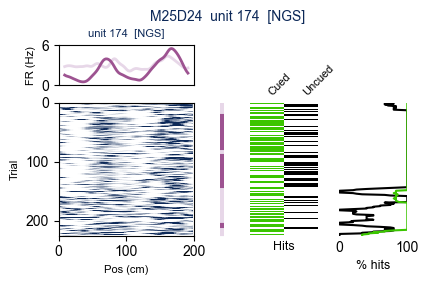

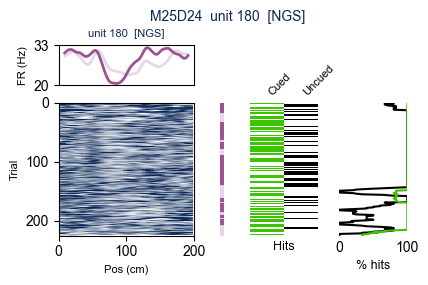

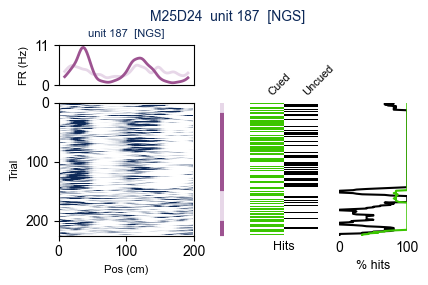

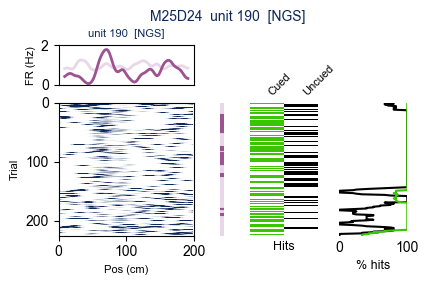

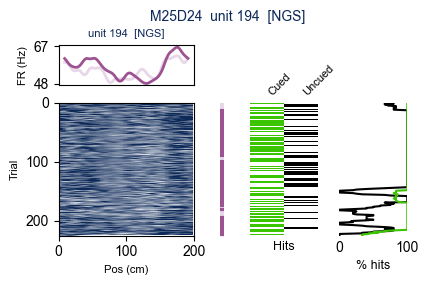

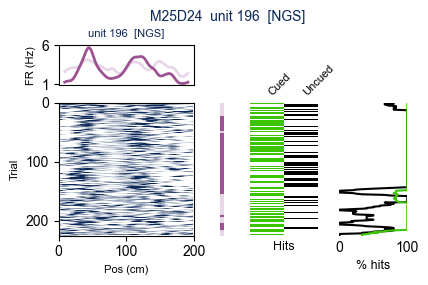

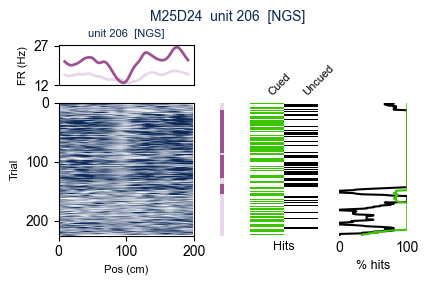

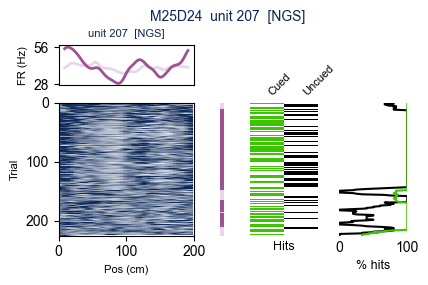

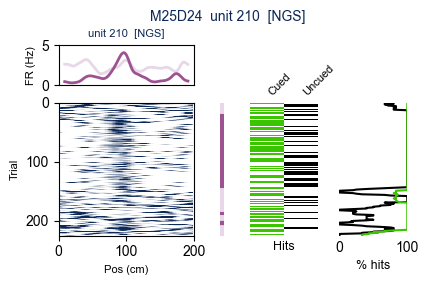

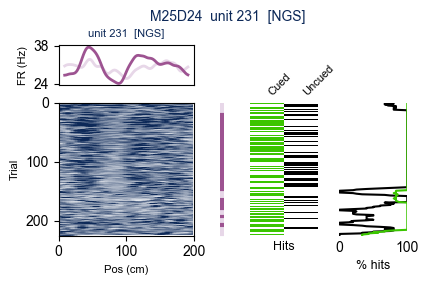

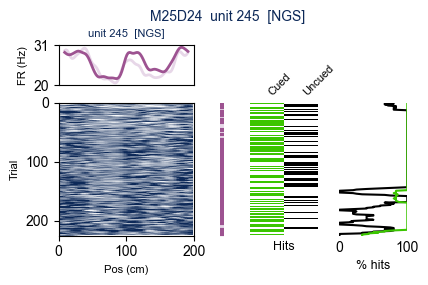

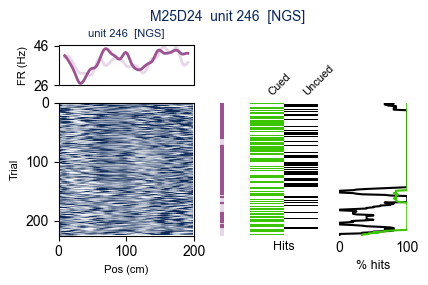

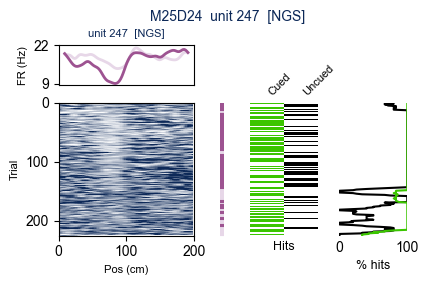

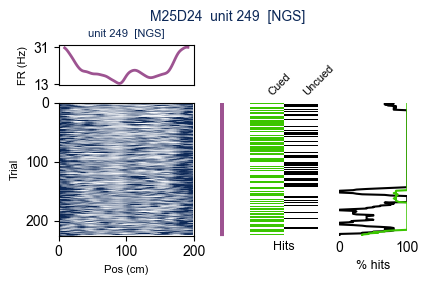

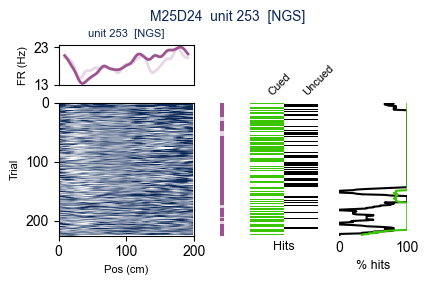

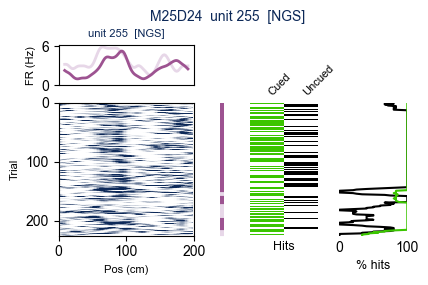

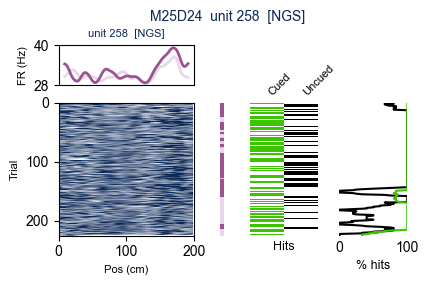

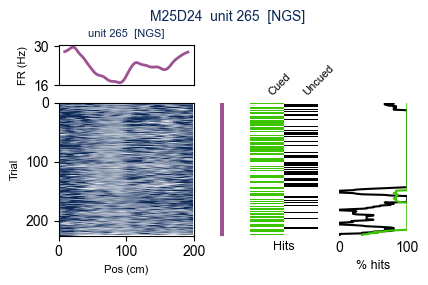

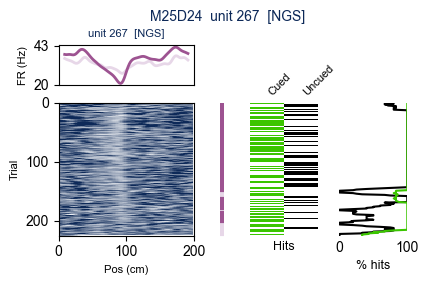

In [7]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

mouse, day = 25, 24

# ── Classify all grid cells and NGS cells ────────────────────────────────────
gcs_tmp, ngs_tmp, _ = classify_cells_both_sessions(
    mouse=mouse, day=day, percentile_threshold=95, verbose=False
)
gcs_tmp = gcs_tmp.sort_values('grid_score', ascending=False)
ngs_tmp = ngs_tmp.sort_values('cluster_id')

gc_ids  = gcs_tmp['cluster_id'].values.tolist()
ngs_ids = ngs_tmp['cluster_id'].values.tolist()

combined_ids    = gc_ids + ngs_ids
combined_labels = [f'unit {cid}' for cid in combined_ids]
combined_colors = [gc_color_dark] * len(gc_ids) + [ngs_color_dark] * len(ngs_ids)
print(f"M{mouse}D{day}: {len(gc_ids)} GC + {len(ngs_ids)} NGS = {len(combined_ids)} cells")

# ── Load VR tuning curves ─────────────────────────────────────────────────────
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False
)
last_ephys_time_bin = clusters[clusters.index[0]].count(
    bin_size=time_bs, time_units='ms'
).index[-1]

max_len = last_ephys_bin // (tl // bs)

# ---- Shared: hits raster ----------------------------------------------------
nb_hit_mask  = make_hit_mask(beh, 'nb')
b_hit_mask   = make_hit_mask(beh, 'b')
n_trials_beh = len(nb_hit_mask)
n_use        = min(max_len, n_trials_beh)

hit_raster      = np.full((2, max_len), np.nan)
hit_raster[0, :n_use][b_hit_mask[:n_use]]  = 1
hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1
hit_cmap = ListedColormap(["white", "#3bc500", "black"])
hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
hit_raster_plot    = np.zeros_like(hit_raster)
hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

# ---- Shared: rolling % hits -------------------------------------------------
window       = 10
kernel       = np.ones(window) / window
nb_type_mask = make_trialtype_mask(beh, 'nb')
b_type_mask  = make_trialtype_mask(beh, 'b')
nb_num = np.convolve(nb_hit_mask.astype(float), kernel, mode='same')
nb_den = np.convolve(nb_type_mask.astype(float), kernel, mode='same')
b_num  = np.convolve(b_hit_mask.astype(float),  kernel, mode='same')
b_den  = np.convolve(b_type_mask.astype(float), kernel, mode='same')
nb_rolling = np.where(nb_den > 0, nb_num / nb_den * 100, np.nan)
b_rolling  = np.where(b_den  > 0, b_num  / b_den  * 100, np.nan)
nb_rolling_full = np.full(max_len, np.nan)
b_rolling_full  = np.full(max_len, np.nan)
nb_rolling_full[:n_use] = nb_rolling[:n_use]
b_rolling_full[:n_use]  = b_rolling[:n_use]

trial_axis = np.arange(max_len)
trial_ylim = (max_len, 0)
_y_all  = np.concatenate([nb_rolling_full, b_rolling_full])
_finite = np.isfinite(_y_all)
pct_xlim = (_y_all[_finite].min(), _y_all[_finite].max()) if _finite.any() else (0.0, 100.0)
if pct_xlim[0] == pct_xlim[1]:
    pct_xlim = (pct_xlim[0] - 5, pct_xlim[1] + 5)

# ---- Shared: task-anchoring colourmaps ──────────────────────────────────────
cmap_ta = ListedColormap(["#e7d7e8", "#9d5391", "white"])
norm_ta = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap_ta.N)

# ---- One figure per cell ────────────────────────────────────────────────────
for cell_id, cell_label, color in zip(combined_ids, combined_labels, combined_colors):
    cell_type = 'GC' if cell_id in gc_ids else 'NGS'
    try:
        if cell_id not in tcs:
            print(f"  {cell_label} ({cell_type}): not in tcs, skipping")
            continue

        tc = gaussian_filter(np.nan_to_num(tcs[cell_id]).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results    = spectral_analysis(tcs_to_use, tl, bs=bs)
        S          = results[3].mean(0)
        max_peaks  = np.argmax(S, axis=0)
        labels_ta  = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta  = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)

        fig = plt.figure(figsize=(rm_figsize[0] * 4.5, rm_figsize[1] * 1.7))
        gs  = mgridspec.GridSpec(
            2, 4,
            height_ratios=[0.3, 1],
            width_ratios=[1, 0.1, 0.5, 0.5],
            figure=fig, wspace=0.3, hspace=0.2,
        )
        ax_avg     = fig.add_subplot(gs[0, 0])
        ax_rate    = fig.add_subplot(gs[1, 0])
        ax_scatter = fig.add_subplot(gs[1, 1])
        ax_hits    = fig.add_subplot(gs[1, 2])
        ax_pct     = fig.add_subplot(gs[1, 3])
        for _col in [1, 2, 3]:
            fig.add_subplot(gs[0, _col]).axis('off')

        # ---- avg profile
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            if mask.sum() > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(f'{cell_label}  [{cell_type}]', fontsize=8, color=color)
        ax_avg.set_ylabel('FR (Hz)', fontsize=8)
        ax_avg.set_xticks([])
        if avg_ys:
            _all_y = np.concatenate(avg_ys)
            ax_avg.set_yticks([int(np.floor(np.nanmin(_all_y))), int(np.ceil(np.nanmax(_all_y)))])

        # ---- rate map
        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster_row = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster_row, aspect='auto', cmap=cmap_ta, norm=norm_ta, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)', fontsize=8)
        ax_rate.set_ylabel('Trial', fontsize=8)

        # ---- scatter strip
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            ax_scatter.scatter(
                np.zeros(mask.sum()), np.where(mask)[0],
                color=plot_color, rasterized=True, s=5, marker='_',
            )
        ax_scatter.set_ylim(0, max_len)
        ax_scatter.invert_yaxis()
        ax_scatter.axis('off')

        # ---- hits raster
        ax_hits.imshow(hit_raster_plot.T, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                       interpolation='nearest', rasterized=False,
                       extent=[-0.5, 1.5, max_len - 0.5, -0.5], origin='upper')
        ax_hits.set_xticks([0, 1])
        ax_hits.xaxis.tick_top()
        ax_hits.set_xticklabels(['Cued', 'Uncued'], fontsize=8, rotation=45, ha='left')
        ax_hits.set_yticks([])
        ax_hits.set_ylim(*trial_ylim)
        ax_hits.set_xlabel('Hits', fontsize=9)
        for spine in ax_hits.spines.values():
            spine.set_visible(False)
        ax_hits.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False,
                            left=False, labelleft=False, length=0)

        # ---- % hits
        ax_pct.plot(nb_rolling_full, trial_axis, color='black', label='Uncued')
        ax_pct.plot(b_rolling_full,  trial_axis, color='#3bc500', label='Cued')
        ax_pct.set_xlabel('% hits', fontsize=9)
        ax_pct.set_yticks([])
        ax_pct.set_ylim(*trial_ylim)
        ax_pct.set_xlim(*pct_xlim)
        ax_pct.set_xticks(np.linspace(pct_xlim[0], pct_xlim[1], 2))
        for spine in ax_pct.spines.values():
            spine.set_visible(False)
        ax_pct.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

        fig.suptitle(f'M{mouse}D{day}  {cell_label}  [{cell_type}]', fontsize=10, color=color, y=1.01)
        plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
        plt.savefig(f'M{mouse}D{day}_{cell_type}_{cell_id}_rate_map.pdf', dpi=300, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"  ERROR {cell_label} ({cell_type}): {e}")
        plt.close('all')

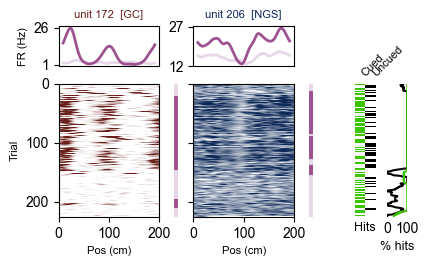

In [8]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

mouse, day = 25, 24

# ── Two specific cells ────────────────────────────────────────────────────────
combined_ids    = [172, 206]
combined_labels = ['unit 172', 'unit 206']
combined_colors = [gc_color_dark, ngs_color_dark]
cell_types      = ['GC', 'NGS']

# ── Load VR tuning curves ─────────────────────────────────────────────────────
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False
)
max_len = last_ephys_bin // (tl // bs)

# ---- Shared: hits raster ----------------------------------------------------
nb_hit_mask  = make_hit_mask(beh, 'nb')
b_hit_mask   = make_hit_mask(beh, 'b')
n_trials_beh = len(nb_hit_mask)
n_use        = min(max_len, n_trials_beh)

hit_raster      = np.full((2, max_len), np.nan)
hit_raster[0, :n_use][b_hit_mask[:n_use]]  = 1
hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1
hit_cmap = ListedColormap(["white", "#3bc500", "black"])
hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
hit_raster_plot    = np.zeros_like(hit_raster)
hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

# ---- Shared: rolling % hits -------------------------------------------------
window       = 10
kernel       = np.ones(window) / window
nb_type_mask = make_trialtype_mask(beh, 'nb')
b_type_mask  = make_trialtype_mask(beh, 'b')
nb_num = np.convolve(nb_hit_mask.astype(float), kernel, mode='same')
nb_den = np.convolve(nb_type_mask.astype(float), kernel, mode='same')
b_num  = np.convolve(b_hit_mask.astype(float),  kernel, mode='same')
b_den  = np.convolve(b_type_mask.astype(float), kernel, mode='same')
nb_rolling = np.where(nb_den > 0, nb_num / nb_den * 100, np.nan)
b_rolling  = np.where(b_den  > 0, b_num  / b_den  * 100, np.nan)
nb_rolling_full = np.full(max_len, np.nan)
b_rolling_full  = np.full(max_len, np.nan)
nb_rolling_full[:n_use] = nb_rolling[:n_use]
b_rolling_full[:n_use]  = b_rolling[:n_use]

trial_axis = np.arange(max_len)
trial_ylim = (max_len, 0)
_y_all  = np.concatenate([nb_rolling_full, b_rolling_full])
_finite = np.isfinite(_y_all)
pct_xlim = (_y_all[_finite].min(), _y_all[_finite].max()) if _finite.any() else (0.0, 100.0)
if pct_xlim[0] == pct_xlim[1]:
    pct_xlim = (pct_xlim[0] - 5, pct_xlim[1] + 5)

# ---- Shared: task-anchoring colourmaps ──────────────────────────────────────
cmap_ta = ListedColormap(["#e7d7e8", "#9d5391", "white"])
norm_ta = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap_ta.N)

# ---- Pre-compute tuning curves for both cells ───────────────────────────────
cell_data = {}
for cell_id in combined_ids:
    try:
        tc = gaussian_filter(np.nan_to_num(tcs[cell_id]).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results    = spectral_analysis(tcs_to_use, tl, bs=bs)
        S          = results[3].mean(0)
        max_peaks  = np.argmax(S, axis=0)
        labels_ta  = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta  = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        cell_data[cell_id] = {'tc': tc, 'labels_ta': labels_ta}
    except Exception as e:
        print(f"  ERROR unit {cell_id}: {e}")
        cell_data[cell_id] = None

# ---- Figure layout: 2 cells + hits + % hits ---------------------------------
# cols: rate_0 | scatter_0 | rate_1 | scatter_1 | spacer | hits | pct
fig = plt.figure(figsize=(rm_figsize[0] * 4.5, rm_figsize[1] * 1.7))
gs  = mgridspec.GridSpec(
    2, 7,
    height_ratios=[0.3, 1],
    width_ratios=[1, 0.1, 1, 0.1, 0.15, 0.2, 0.2],
    figure=fig, wspace=0.3, hspace=0.2,
)

# Top row
ax_avg_0 = fig.add_subplot(gs[0, 0])
ax_avg_1 = fig.add_subplot(gs[0, 2])
for _c in [1, 3, 4, 5, 6]:
    fig.add_subplot(gs[0, _c]).axis('off')

# Bottom row — rate maps share y-axis
ax_rate_0    = fig.add_subplot(gs[1, 0])
ax_scatter_0 = fig.add_subplot(gs[1, 1])
ax_rate_1    = fig.add_subplot(gs[1, 2], sharey=ax_rate_0)
ax_scatter_1 = fig.add_subplot(gs[1, 3])
ax_spacer    = fig.add_subplot(gs[1, 4]); ax_spacer.axis('off')
ax_hits      = fig.add_subplot(gs[1, 5])
ax_pct       = fig.add_subplot(gs[1, 6])

ax_avgs     = [ax_avg_0,     ax_avg_1]
ax_rates    = [ax_rate_0,    ax_rate_1]
ax_scatters = [ax_scatter_0, ax_scatter_1]

# ---- Populate per-cell panels -----------------------------------------------
for i, (cell_id, cell_label, color, cell_type) in enumerate(
        zip(combined_ids, combined_labels, combined_colors, cell_types)):
    ax_avg  = ax_avgs[i]
    ax_rate = ax_rates[i]
    ax_sc   = ax_scatters[i]

    if cell_data[cell_id] is None:
        ax_avg.axis('off'); ax_rate.axis('off'); ax_sc.axis('off')
        continue

    tc        = cell_data[cell_id]['tc']
    labels_ta = cell_data[cell_id]['labels_ta']

    # avg profile
    avg_ys = []
    for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
        mask = labels_ta == label_val
        if mask.sum() > 5:
            x, y = get_avg_profile(tc, bs, tl, mask=mask)
            ax_avg.plot(x, y, color=plot_color, linewidth=2)
            avg_ys.append(y)
    ax_avg.set_title(f'{cell_label}  [{cell_type}]', fontsize=8, color=color)
    ax_avg.set_xticks([])
    if i == 0:
        ax_avg.set_ylabel('FR (Hz)', fontsize=8)
    if avg_ys:
        _all_y = np.concatenate(avg_ys)
        ax_avg.set_yticks([int(np.floor(np.nanmin(_all_y))), int(np.ceil(np.nanmax(_all_y)))])

    # rate map
    plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
    raster_row = np.expand_dims(labels_ta, axis=0)
    ax_rate.imshow(raster_row, aspect='auto', cmap=cmap_ta, norm=norm_ta, interpolation='none',
                   extent=[*ax_rate.get_xlim(),
                            ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                            ax_rate.get_ylim()[0]])
    ax_rate.set_xlabel('Pos (cm)', fontsize=8)
    if i == 0:
        ax_rate.set_ylabel('Trial', fontsize=8)
    else:
        plt.setp(ax_rate.get_yticklabels(), visible=False)

    # scatter strip
    for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
        mask = labels_ta == label_val
        ax_sc.scatter(
            np.zeros(mask.sum()), np.where(mask)[0],
            color=plot_color, rasterized=True, s=5, marker='_',
        )
    ax_sc.set_ylim(0, max_len)
    ax_sc.invert_yaxis()
    ax_sc.axis('off')

# ---- Hits raster ------------------------------------------------------------
ax_hits.imshow(hit_raster_plot.T, aspect='auto', cmap=hit_cmap, norm=hit_norm,
               interpolation='nearest', rasterized=False,
               extent=[-0.5, 1.5, max_len - 0.5, -0.5], origin='upper')
ax_hits.set_xticks([0, 1])
ax_hits.xaxis.tick_top()
ax_hits.set_xticklabels(['Cued', 'Uncued'], fontsize=8, rotation=45, ha='left')
ax_hits.set_yticks([])
ax_hits.set_ylim(*trial_ylim)
ax_hits.set_xlabel('Hits', fontsize=9)
for spine in ax_hits.spines.values():
    spine.set_visible(False)
ax_hits.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False,
                    left=False, labelleft=False, length=0)

# ---- % hits -----------------------------------------------------------------
ax_pct.plot(nb_rolling_full, trial_axis, color='black', label='Uncued')
ax_pct.plot(b_rolling_full,  trial_axis, color='#3bc500', label='Cued')
ax_pct.set_xlabel('% hits', fontsize=9)
ax_pct.set_yticks([])
ax_pct.set_ylim(*trial_ylim)
ax_pct.set_xlim(*pct_xlim)
ax_pct.set_xticks(np.linspace(pct_xlim[0], pct_xlim[1], 2))
for spine in ax_pct.spines.values():
    spine.set_visible(False)
ax_pct.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
plt.savefig(f'M{mouse}D{day}_unit172_unit207_rate_maps.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
def get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False):
    trial_numbers = np.array(beh['trial_number'])
    position = np.array(beh['P'])
    speed = np.array(beh['S'])
    trial_numbers = trial_numbers[:len(speed)]
    position = position[:len(speed)]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    if sort:
        sorted_cats = trial_df.groupby(by=['context', 'type', 'performance'])
        sorted_trial_indices = []
        for _, cat_df in sorted_cats:
            sorted_trial_indices.extend(cat_df.index.tolist())
        trial_order = sorted_trial_indices
    else:
        trial_order = trial_df.index.tolist()

    speed_matrix = np.full((len(trial_order), n_pos_bins), np.nan)
    trial_type_colors = []
    for i, ti in enumerate(trial_order):
        trial_num = trial_df['number'][ti]
        mask = (trial_numbers == trial_num)
        pos_trial = position[mask]
        speed_trial = speed[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed_profile = bin_sums / bin_counts
        speed_matrix[i, :] = speed_profile
        trial_type = trial_df['type'][ti]
        color = get_color_for_group(('rz1', trial_type, 'hit')) if isinstance(trial_type, str) else 'grey'
        trial_type_colors.append(color)
    return speed_matrix, trial_type_colors, trial_order, pos_bins


def sem_nan(a, axis=0):
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    return np.where(n > 1, std / np.sqrt(n), np.nan)


def trial_type_stats_from_speed_matrix(beh, last_ephys_bin, tl, bs, speed_matrix, trial_order):
    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]
    pos_bins = np.linspace(0, tl, int(tl / 5) + 1)
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2
    unique_types = [t for t in np.unique(np.array(trial_types_order)) if str(t) != 'nan']
    type_means, type_sems = {}, {}
    for t in unique_types:
        rows = [i for i, tt in enumerate(trial_types_order) if tt == t]
        data = speed_matrix[rows, :]
        type_means[t] = np.nanmean(data, axis=0)
        type_sems[t] = sem_nan(data, axis=0)
    return pos_centers, unique_types, type_means, type_sems


Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


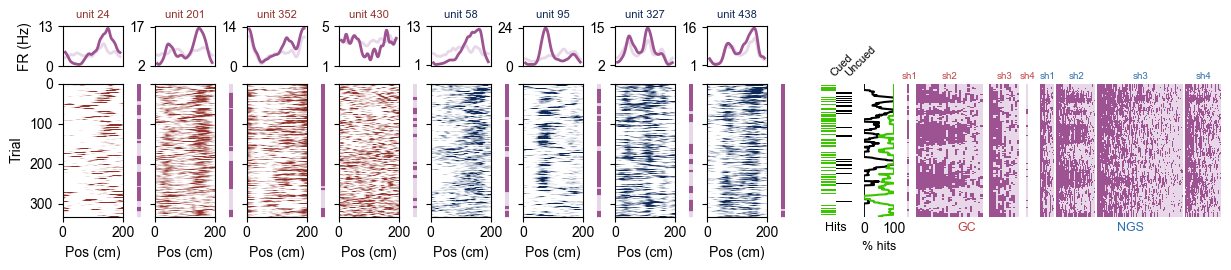

Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


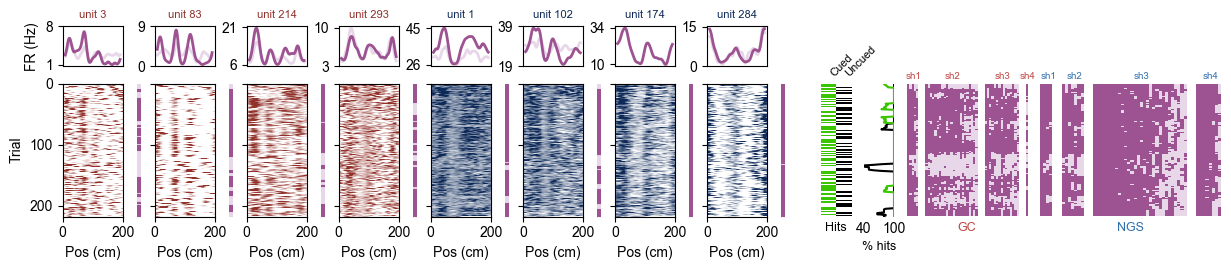

In [10]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

ngs_color = "#3171ae"
gc_color  = "#c04744"

mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[24, 201, 352, 430, 58, 95, 327, 438],
                       [3, 83, 214, 293, 1, 102, 174, 284]]
example_cluster_labels = [['unit 24', 'unit 201', 'unit 352', 'unit 430', 'unit 58', 'unit 95', 'unit 327', 'unit 438'],
                           ['unit 3', 'unit 83', 'unit 214', 'unit 293', 'unit 1', 'unit 102', 'unit 174', 'unit 284']]
example_cluster_colors = [['#90312a', '#90312a', '#90312a', '#90312a', ngs_color_dark, ngs_color_dark, ngs_color_dark, ngs_color_dark],
                           ['#90312a', '#90312a', '#90312a', '#90312a', ngs_color_dark, ngs_color_dark, ngs_color_dark, ngs_color_dark]]

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(
    mice, days, example_cluster_ids, example_cluster_labels, example_cluster_colors
):
    print(f"Processing Mouse {mouse} Day {day}...")
    gcs, ngs, all_cells = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all_cells)} total cells')

    # ---- GCS raster prep ----
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gc_shank_ids = sorted(gcs['shank_id'].unique())
    gcs_labels_list, gcs_shank_order = [], []
    for shank in gc_shank_ids:
        for cluster_id in gcs[gcs['shank_id'] == shank].cluster_id.values:
            try:
                tc = tcs[cluster_id] if cluster_id in tcs else None
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                tcs_to_use = {cluster_id: tc, 1000: tc}
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                S = results[3].mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                gcs_labels_list.append(labels)
                gcs_shank_order.append(shank)
            except Exception as e:
                print(f"Error processing GCS cluster {cluster_id}: {e}")

    # Sort GCS by shank then by task-anchored sum descending
    gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels_list])
    gcs_shank_arr  = np.array(gcs_shank_order)
    gc_order = []
    for shank in gc_shank_ids:
        shank_indices = np.where(gcs_shank_arr == shank)[0]
        gc_order.extend(shank_indices[np.argsort(-gcs_label_sums[shank_indices])].tolist())
    gcs_labels_list = [gcs_labels_list[i] for i in gc_order]
    gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

    # ---- NGS raster prep ----
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    shank_ids = sorted(ngs['shank_id'].unique())
    global_cell_list, global_shank_list = [], []
    for shank in shank_ids:
        for cid in ngs[ngs['shank_id'] == shank].cluster_id.values:
            global_cell_list.append(cid)
            global_shank_list.append(shank)

    all_labels_list, cell_shank_order = [], []
    for target_cluster_id, shank in zip(global_cell_list, global_shank_list):
        try:
            tc = tcs[target_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            tcs_to_use = {target_cluster_id: tc, 1000: tc}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
            labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
        except Exception as e:
            print(f"Error processing NGS cluster {target_cluster_id}: {e}")
            labels = np.full(last_ephys_bin, np.nan)
        all_labels_list.append(labels)
        cell_shank_order.append(shank)

    # Sort NGS within each shank by task-anchored sum descending
    shank_arr  = np.array(cell_shank_order)
    label_sums = np.array([np.nansum(lab == 1) for lab in all_labels_list])
    order = []
    for shank in shank_ids:
        shank_indices = np.where(shank_arr == shank)[0]
        order.extend(shank_indices[np.argsort(-label_sums[shank_indices])].tolist())
    order = np.array(order)

    max_len = max(
        [len(lab) for lab in all_labels_list] + [len(lab) for lab in gcs_labels_list]
    )

    # Build GCS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    gc_blocks = []
    for shank in gc_shank_ids:
        block = [gcs_labels_list[i] for i in range(len(gcs_labels_list)) if gcs_shank_order[i] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        gc_blocks.append(bm)
    labels_matrix_gcs = gc_blocks[0]
    for blk in gc_blocks[1:]:
        labels_matrix_gcs = np.vstack([labels_matrix_gcs, np.full((3, max_len), np.nan), blk])

    # Build NGS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    ngs_blocks = []
    for shank in shank_ids:
        block = [all_labels_list[idx] for idx in order if cell_shank_order[idx] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        ngs_blocks.append(bm)
    labels_matrix_ngs = ngs_blocks[0]
    for blk in ngs_blocks[1:]:
        labels_matrix_ngs = np.vstack([labels_matrix_ngs, np.full((3, max_len), np.nan), blk])

    # ---- Hits raster ----
    nb_hit_mask = make_hit_mask(beh, 'nb')
    b_hit_mask  = make_hit_mask(beh, 'b')
    n_trials_beh = len(nb_hit_mask)
    n_use = min(max_len, n_trials_beh)
    hit_raster = np.full((2, max_len), np.nan)
    hit_raster[0, :n_use][b_hit_mask[:n_use]]  = 1
    hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1
    hit_cmap = ListedColormap(["white", "#3bc500", "black"])
    hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
    hit_raster_plot = np.zeros_like(hit_raster)
    hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
    hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

    # ---- Rolling hit rate ----
    window = 10
    kernel = np.ones(window) / window
    nb_type_mask = make_trialtype_mask(beh, 'nb')
    b_type_mask  = make_trialtype_mask(beh, 'b')
    nb_num = np.convolve(nb_hit_mask.astype(float), kernel, mode='same')
    nb_den = np.convolve(nb_type_mask.astype(float), kernel, mode='same')
    b_num  = np.convolve(b_hit_mask.astype(float),  kernel, mode='same')
    b_den  = np.convolve(b_type_mask.astype(float), kernel, mode='same')
    nb_rolling = np.where(nb_den > 0, nb_num / nb_den * 100, np.nan)
    b_rolling  = np.where(b_den  > 0, b_num  / b_den  * 100, np.nan)
    nb_rolling_full = np.full(max_len, np.nan)
    b_rolling_full  = np.full(max_len, np.nan)
    nb_rolling_full[:n_use] = nb_rolling[:n_use]
    b_rolling_full[:n_use]  = b_rolling[:n_use]

    # ---- Figure layout ----
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_main_cols = 2 * n_cells
    main_width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    # Extra column widths: spacer + hits + pct + gcs + ngs
    n_gc_cells = labels_matrix_gcs.shape[0]
    n_ngs_cells = labels_matrix_ngs.shape[0]
    extra_widths = [0.15, 0.5, 0.5, 2, 3]
    n_total_cols = n_main_cols + 5

    fig = plt.figure(figsize=(rm_figsize[0] * (n_cells * 1.1 + sum(extra_widths)), rm_figsize[1] * 1.7))
    gs = mgridspec.GridSpec(
        2, n_total_cols,
        height_ratios=[0.3, 1],
        width_ratios=main_width_ratios + extra_widths,
        figure=fig, wspace=0.3, hspace=0.2,
    )

    # Main 2 × n_main_cols axes
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(n_main_cols)] for r in range(2)])

    # Spacer column — row 1, axes off
    ax_spacer = fig.add_subplot(gs[1, n_main_cols])
    ax_spacer.axis('off')

    # 4 extra axes — row 1 only, matching the height of the trial/rate map row
    ax_hits = fig.add_subplot(gs[1, n_main_cols + 1])
    ax_pct  = fig.add_subplot(gs[1, n_main_cols + 2])
    ax_gcs  = fig.add_subplot(gs[1, n_main_cols + 3])
    ax_ngs  = fig.add_subplot(gs[1, n_main_cols + 4])

    # Hide the row-0 cells above the spacer and 4 extra columns
    for col_offset in range(5):
        fig.add_subplot(gs[0, n_main_cols + col_offset]).axis('off')

    # ---- Populate main cell plots ----
    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main    = 2 * i
        col_scatter = 2 * i + 1
        ax_avg     = axes[0, col_main]
        ax_rate    = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        S = results[3].mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            if mask.sum() > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            ax_avg.set_yticks([int(np.floor(np.nanmin(all_y))), int(np.ceil(np.nanmax(all_y)))])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            ax_scatter.scatter(
                np.zeros(mask.sum()), np.where(mask)[0],
                color=plot_color, rasterized=True, s=5, marker='_',
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        axes[1, i * 2 + 1].set_ylim(0, len(labels_ta))
        axes[1, i * 2 + 1].invert_yaxis()
        if i != 0:
            axes[1, i * 2].set_yticklabels([])
    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')

    trial_ylim = (max_len, 0)  # inverted: 0 at top, max_len at bottom

    # ---- Hits raster column: transposed so trials run vertically ----
    # hit_raster_plot shape: (2, max_len) → transpose to (max_len, 2)
    ax_hits.imshow(hit_raster_plot.T, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                   interpolation='nearest', rasterized=False,
                   extent=[-0.5, 1.5, max_len - 0.5, -0.5], origin='upper')
    ax_hits.set_xticks([0, 1])
    ax_hits.xaxis.tick_top()
    ax_hits.set_xticklabels(['Cued', 'Uncued'], fontsize=8, rotation=45, ha='left')
    ax_hits.set_yticks([])
    ax_hits.set_ylim(*trial_ylim)
    ax_hits.set_xlabel('Hits', fontsize=9)
    for spine in ax_hits.spines.values():
        spine.set_visible(False)
    ax_hits.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, left=False, labelleft=False, length=0)

    # ---- % hits column: x=%, y=trial ----
    trial_axis = np.arange(max_len)
    ax_pct.plot(nb_rolling_full, trial_axis, color='black', label='NB')
    ax_pct.plot(b_rolling_full,  trial_axis, color='#3bc500', label='B')
    ax_pct.set_xlabel('% hits', fontsize=9)
    ax_pct.set_yticks([])
    ax_pct.set_ylim(*trial_ylim)
    y_all = np.concatenate([nb_rolling_full, b_rolling_full])
    finite = np.isfinite(y_all)
    if finite.any():
        x_min, x_max = y_all[finite].min(), y_all[finite].max()
        if x_min == x_max:
            margin = 0.05 * max(abs(x_min), 1.0)
            x_min -= margin; x_max += margin
    else:
        x_min, x_max = 0.0, 100.0
    ax_pct.set_xlim(x_min, x_max)
    ax_pct.set_xticks(np.linspace(x_min, x_max, 2))
    for spine in ax_pct.spines.values():
        spine.set_visible(False)
    ax_pct.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

    # ---- GCS raster column: transposed so trials run vertically ----
    # labels_matrix_gcs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_gc_cols = labels_matrix_gcs.shape[0]
    ax_gcs.imshow(labels_matrix_gcs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_gc_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_gcs.set_xlabel('GC', fontsize=9, color=gc_color)
    ax_gcs.set_xticks([])
    ax_gcs.set_yticks([])
    ax_gcs.set_ylim(*trial_ylim)
    for spine in ax_gcs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_gc = 0
    for blk, shank in zip(gc_blocks, gc_shank_ids):
        x_mid = x_gc + blk.shape[0] / 2
        ax_gcs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=gc_color, clip_on=False)
        x_gc += blk.shape[0] + 3

    # ---- NGS raster column: transposed so trials run vertically ----
    # labels_matrix_ngs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_ngs_cols = labels_matrix_ngs.shape[0]
    ax_ngs.imshow(labels_matrix_ngs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_ngs_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_ngs.set_xlabel('NGS', fontsize=9, color=ngs_color)
    ax_ngs.set_xticks([])
    ax_ngs.set_yticks([])
    ax_ngs.set_ylim(*trial_ylim)
    for spine in ax_ngs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_ngs = 0
    for blk, shank in zip(ngs_blocks, shank_ids):
        x_mid = x_ngs + blk.shape[0] / 2
        ax_ngs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=ngs_color, clip_on=False)
        x_ngs += blk.shape[0] + 3

    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank_v2.pdf')
    plt.show()


Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


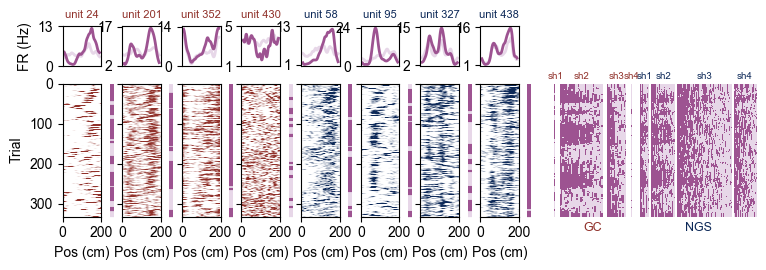

Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


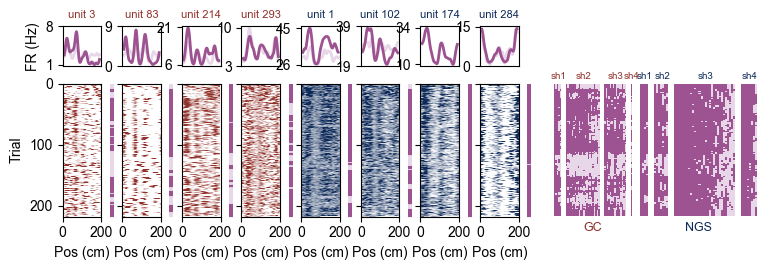

In [11]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

ngs_color = ngs_color_dark
gc_color  = "#90312a"

mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[24, 201, 352, 430, 58, 95, 327, 438],
                       [3, 83, 214, 293, 1, 102, 174, 284]]
example_cluster_labels = [['unit 24', 'unit 201', 'unit 352', 'unit 430', 'unit 58', 'unit 95', 'unit 327', 'unit 438'],
                           ['unit 3', 'unit 83', 'unit 214', 'unit 293', 'unit 1', 'unit 102', 'unit 174', 'unit 284']]
example_cluster_colors = [['#90312a', '#90312a', '#90312a', '#90312a', ngs_color_dark, ngs_color_dark, ngs_color_dark, ngs_color_dark],
                           ['#90312a', '#90312a', '#90312a', '#90312a', ngs_color_dark, ngs_color_dark, ngs_color_dark, ngs_color_dark]]

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(
    mice, days, example_cluster_ids, example_cluster_labels, example_cluster_colors
):
    print(f"Processing Mouse {mouse} Day {day}...")
    gcs, ngs, all_cells = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all_cells)} total cells')

    # ---- GCS raster prep ----
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gc_shank_ids = sorted(gcs['shank_id'].unique())
    gcs_labels_list, gcs_shank_order = [], []
    for shank in gc_shank_ids:
        for cluster_id in gcs[gcs['shank_id'] == shank].cluster_id.values:
            try:
                tc = tcs[cluster_id] if cluster_id in tcs else None
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                tcs_to_use = {cluster_id: tc, 1000: tc}
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                S = results[3].mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                gcs_labels_list.append(labels)
                gcs_shank_order.append(shank)
            except Exception as e:
                print(f"Error processing GCS cluster {cluster_id}: {e}")

    # Sort GCS by shank then by task-anchored sum descending
    gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels_list])
    gcs_shank_arr  = np.array(gcs_shank_order)
    gc_order = []
    for shank in gc_shank_ids:
        shank_indices = np.where(gcs_shank_arr == shank)[0]
        gc_order.extend(shank_indices[np.argsort(-gcs_label_sums[shank_indices])].tolist())
    gcs_labels_list = [gcs_labels_list[i] for i in gc_order]
    gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

    # ---- NGS raster prep ----
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    shank_ids = sorted(ngs['shank_id'].unique())
    global_cell_list, global_shank_list = [], []
    for shank in shank_ids:
        for cid in ngs[ngs['shank_id'] == shank].cluster_id.values:
            global_cell_list.append(cid)
            global_shank_list.append(shank)

    all_labels_list, cell_shank_order = [], []
    for target_cluster_id, shank in zip(global_cell_list, global_shank_list):
        try:
            tc = tcs[target_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            tcs_to_use = {target_cluster_id: tc, 1000: tc}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
            labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
        except Exception as e:
            print(f"Error processing NGS cluster {target_cluster_id}: {e}")
            labels = np.full(last_ephys_bin, np.nan)
        all_labels_list.append(labels)
        cell_shank_order.append(shank)

    # Sort NGS within each shank by task-anchored sum descending
    shank_arr  = np.array(cell_shank_order)
    label_sums = np.array([np.nansum(lab == 1) for lab in all_labels_list])
    order = []
    for shank in shank_ids:
        shank_indices = np.where(shank_arr == shank)[0]
        order.extend(shank_indices[np.argsort(-label_sums[shank_indices])].tolist())
    order = np.array(order)

    max_len = max(
        [len(lab) for lab in all_labels_list] + [len(lab) for lab in gcs_labels_list]
    )

    # Build GCS matrix with 3 blank rows between shanks
    gc_blocks = []
    for shank in gc_shank_ids:
        block = [gcs_labels_list[i] for i in range(len(gcs_labels_list)) if gcs_shank_order[i] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        gc_blocks.append(bm)
    labels_matrix_gcs = gc_blocks[0]
    for blk in gc_blocks[1:]:
        labels_matrix_gcs = np.vstack([labels_matrix_gcs, np.full((3, max_len), np.nan), blk])

    # Build NGS matrix with 3 blank rows between shanks
    ngs_blocks = []
    for shank in shank_ids:
        block = [all_labels_list[idx] for idx in order if cell_shank_order[idx] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        ngs_blocks.append(bm)
    labels_matrix_ngs = ngs_blocks[0]
    for blk in ngs_blocks[1:]:
        labels_matrix_ngs = np.vstack([labels_matrix_ngs, np.full((3, max_len), np.nan), blk])

    # ---- Figure layout ----
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_main_cols = 2 * n_cells
    main_width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    # Extra column widths: spacer + gcs + ngs (hits and pct removed)
    extra_widths = [0.15, 2, 3]
    n_total_cols = n_main_cols + 3

    fig = plt.figure(figsize=(rm_figsize[0] * (3.8 + sum(extra_widths)), rm_figsize[1] * 1.7))
    gs = mgridspec.GridSpec(
        2, n_total_cols,
        height_ratios=[0.3, 1],
        width_ratios=main_width_ratios + extra_widths,
        figure=fig, wspace=0.3, hspace=0.2,
    )

    # Main 2 × n_main_cols axes
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(n_main_cols)] for r in range(2)])

    # Spacer column — row 1, axis off
    ax_spacer = fig.add_subplot(gs[1, n_main_cols])
    ax_spacer.axis('off')

    # GCS and NGS raster axes
    ax_gcs = fig.add_subplot(gs[1, n_main_cols + 1])
    ax_ngs = fig.add_subplot(gs[1, n_main_cols + 2])

    # Hide the row-0 cells above the spacer and extra columns
    for col_offset in range(3):
        fig.add_subplot(gs[0, n_main_cols + col_offset]).axis('off')

    # ---- Populate main cell plots ----
    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main    = 2 * i
        col_scatter = 2 * i + 1
        ax_avg     = axes[0, col_main]
        ax_rate    = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        S = results[3].mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            if mask.sum() > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            ax_avg.set_yticks([int(np.floor(np.nanmin(all_y))), int(np.ceil(np.nanmax(all_y)))])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            ax_scatter.scatter(
                np.zeros(mask.sum()), np.where(mask)[0],
                color=plot_color, rasterized=True, s=5, marker='_',
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        axes[1, i * 2 + 1].set_ylim(0, len(labels_ta))
        axes[1, i * 2 + 1].invert_yaxis()
        if i != 0:
            axes[1, i * 2].set_yticklabels([])
    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')

    trial_ylim = (max_len, 0)  # inverted: 0 at top, max_len at bottom

    # ---- GCS raster column ----
    n_gc_cols = labels_matrix_gcs.shape[0]
    ax_gcs.imshow(labels_matrix_gcs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_gc_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_gcs.set_xlabel('GC', fontsize=9, color=gc_color)
    ax_gcs.set_xticks([])
    ax_gcs.set_yticks([])
    ax_gcs.set_ylim(*trial_ylim)
    for spine in ax_gcs.spines.values():
        spine.set_visible(False)
    x_gc = 0
    for blk, shank in zip(gc_blocks, gc_shank_ids):
        x_mid = x_gc + blk.shape[0] / 2
        ax_gcs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=gc_color, clip_on=False)
        x_gc += blk.shape[0] + 3

    # ---- NGS raster column ----
    n_ngs_cols = labels_matrix_ngs.shape[0]
    ax_ngs.imshow(labels_matrix_ngs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_ngs_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_ngs.set_xlabel('NGS', fontsize=9, color=ngs_color)
    ax_ngs.set_xticks([])
    ax_ngs.set_yticks([])
    ax_ngs.set_ylim(*trial_ylim)
    for spine in ax_ngs.spines.values():
        spine.set_visible(False)
    x_ngs = 0
    for blk, shank in zip(ngs_blocks, shank_ids):
        x_mid = x_ngs + blk.shape[0] / 2
        ax_ngs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=ngs_color, clip_on=False)
        x_ngs += blk.shape[0] + 3

    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank_v2.pdf')
    plt.show()

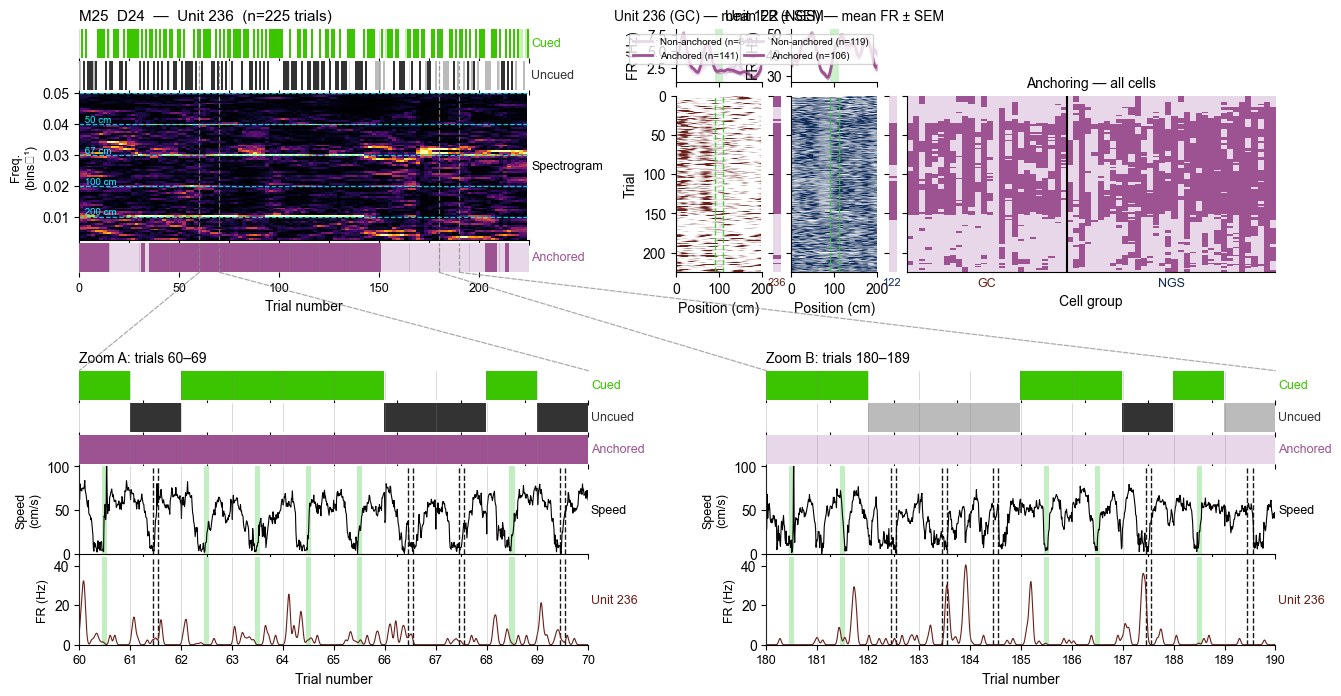

In [100]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches

# ═══════════════════════════════════════════════════════════════════════════════
EXAMPLE_MOUSE   = 25
EXAMPLE_DAY     = 24
EXAMPLE_CELL    = 236    # GC
EXAMPLE_CELL_2  = 122    # NGS
ZOOM1_START     = 60
ZOOM1_END       = 70
ZOOM2_START     = 180
ZOOM2_END       = 190
# ═══════════════════════════════════════════════════════════════════════════════

COLOR_ANCHOR     = '#9d5391'
COLOR_NON_ANCHOR = '#e7d7e8'
gc_color         = gc_color_dark
ngs_color        = ngs_color_dark
COLOR_B_HIT      = '#3bc500'
COLOR_B_MISS     = '#c8f0b0'
COLOR_NB_HIT     = '#333333'
COLOR_NB_MISS    = '#bbbbbb'
COLOR_SPEED      = 'black'
COLOR_ZOOM_GUIDE = '#888888'
COLOR_RZ         = 'limegreen'

# ── Load ──────────────────────────────────────────────────────────────────────
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    EXAMPLE_MOUSE, EXAMPLE_DAY, apply_zscore=False, apply_guassian_filter=False
)
rz_start = 90.0
rz_end   = 110.0
bpt      = int(tl / bs)

# ── Cell 1 (GC) ───────────────────────────────────────────────────────────────
tc1 = gaussian_filter(np.nan_to_num(tcs[EXAMPLE_CELL]).astype(np.float64), sigma=2.5)
tc1 = tc1[:last_ephys_bin]

res1        = spectral_analysis({EXAMPLE_CELL: tc1, 1000: tc1}, tl, bs=bs)
S_cell1     = res1[3][0]
t_spec      = res1[4]
fvalid      = res1[5]
t_dist_spec = t_spec * bs

target_freqs  = np.arange(1, 6) * bs / tl
GRID_FREQ_IDX = [int(np.argmin(np.abs(fvalid - f))) for f in target_freqs]
grid_freqs    = fvalid[GRID_FREQ_IDX]

S_avg1      = res1[3].mean(0)
lbl_idx1    = np.isin(np.argmax(S_avg1, axis=0), GRID_FREQ_IDX).astype(int)
labels_ta1  = get_kmeans_spatial_labels(tc1, lbl_idx1, bs=bs, tl=tl)
n_trials1   = min(len(labels_ta1), len(tc1) // bpt)
labels_ta1  = labels_ta1[:n_trials1]
tc_2d1      = tc1[:n_trials1 * bpt].reshape(n_trials1, bpt)

# ── Cell 2 (NGS) ──────────────────────────────────────────────────────────────
tc2 = gaussian_filter(np.nan_to_num(tcs[EXAMPLE_CELL_2]).astype(np.float64), sigma=2.5)
tc2 = tc2[:last_ephys_bin]

res2        = spectral_analysis({EXAMPLE_CELL_2: tc2, 1000: tc2}, tl, bs=bs)
S_cell2     = res2[3][0]
fvalid2     = res2[5]

GFI2        = [int(np.argmin(np.abs(fvalid2 - f))) for f in target_freqs]
S_avg2      = res2[3].mean(0)
lbl_idx2    = np.isin(np.argmax(S_avg2, axis=0), GFI2).astype(int)
labels_ta2  = get_kmeans_spatial_labels(tc2, lbl_idx2, bs=bs, tl=tl)
n_trials2   = min(len(labels_ta2), len(tc2) // bpt)
labels_ta2  = labels_ta2[:n_trials2]
tc_2d2      = tc2[:n_trials2 * bpt].reshape(n_trials2, bpt)

# common session trial count
n_trials   = min(n_trials1, n_trials2)
labels_ta1 = labels_ta1[:n_trials];  tc_2d1 = tc_2d1[:n_trials]
labels_ta2 = labels_ta2[:n_trials];  tc_2d2 = tc_2d2[:n_trials]

# ── Per-trial signals ─────────────────────────────────────────────────────────
nb_hit_mask  = make_hit_mask(beh, 'nb')
b_hit_mask   = make_hit_mask(beh, 'b')
nb_type_mask = make_trialtype_mask(beh, 'nb')
b_type_mask  = make_trialtype_mask(beh, 'b')

trial_num_arr = np.array(beh['trial_number'])
pos_arr       = np.array(beh['P'])
speed_arr     = np.array(beh['S'])
pos_bins      = np.linspace(0, tl, bpt + 1)

speed_2d = np.full((n_trials, bpt), np.nan)
for t in range(n_trials):
    m = trial_num_arr == (t + 1)
    if not m.any(): continue
    bsums, _ = np.histogram(pos_arr[m], bins=pos_bins, weights=speed_arr[m])
    bcnt,  _ = np.histogram(pos_arr[m], bins=pos_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        speed_2d[t] = np.where(bcnt > 0, bsums / bcnt, np.nan)

def _make_hit_display(hit_mask, type_mask, n):
    arr = np.zeros(n, dtype=float)
    nt  = min(len(type_mask), len(hit_mask), n)
    arr[:nt] = np.where(type_mask[:nt], np.where(hit_mask[:nt], 2.0, 1.0), 0.0)
    return arr

b_display       = _make_hit_display(b_hit_mask,  b_type_mask,  n_trials)
nb_display      = _make_hit_display(nb_hit_mask, nb_type_mask, n_trials)
anchor_display1 = np.where(np.isnan(labels_ta1.astype(float)), 2.0, labels_ta1.astype(float))
anchor_display2 = np.where(np.isnan(labels_ta2.astype(float)), 2.0, labels_ta2.astype(float))

dist_total   = n_trials * tl
z0_1, z1_1   = max(0, ZOOM1_START), min(n_trials, ZOOM1_END)
z0_2, z1_2   = max(0, ZOOM2_START), min(n_trials, ZOOM2_END)
dist_start_1, dist_end_1 = z0_1 * tl, z1_1 * tl
dist_start_2, dist_end_2 = z0_2 * tl, z1_2 * tl

# ── Anchoring raster for all cells ────────────────────────────────────────────
gcs_df, ngs_df, _ = classify_cells_both_sessions(
    mouse=EXAMPLE_MOUSE, day=EXAMPLE_DAY, percentile_threshold=95, verbose=False
)
gc_ids  = gcs_df.sort_values('grid_score', ascending=False)['cluster_id'].values.tolist()
ngs_ids = ngs_df.sort_values('cluster_id')['cluster_id'].values.tolist()
all_ids = [cid for cid in gc_ids + ngs_ids if cid in tcs]
n_gc    = sum(1 for cid in gc_ids if cid in tcs)
n_cells = len(all_ids)

tc_dict = {cid: gaussian_filter(np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
           for cid in all_ids}

res_batch = spectral_analysis(tc_dict, tl, bs=bs)
Sxs_batch = res_batch[3]
fvalid_b  = res_batch[5]
gfi_b     = [int(np.argmin(np.abs(fvalid_b - f))) for f in target_freqs]

raster_arr = np.full((n_cells, n_trials), 2.0)
for i, cid in enumerate(all_ids):
    tc_c  = tc_dict[cid]
    li_c  = np.isin(np.argmax(Sxs_batch[i], axis=0), gfi_b).astype(int)
    lab_c = get_kmeans_spatial_labels(tc_c, li_c, bs=bs, tl=tl)
    nt_c  = min(len(lab_c), len(tc_c) // bpt, n_trials)
    raster_arr[i, :nt_c] = np.where(
        np.isnan(lab_c[:nt_c].astype(float)), 2.0, lab_c[:nt_c].astype(float)
    )

# ── Colour maps ───────────────────────────────────────────────────────────────
b_cmap      = ListedColormap(['white', COLOR_B_MISS,     COLOR_B_HIT])
nb_cmap     = ListedColormap(['white', COLOR_NB_MISS,    COLOR_NB_HIT])
hit_norm    = BoundaryNorm([0, 0.5, 1.5, 2.5], 3)
anchor_cmap = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
anchor_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)

# ── Layout ────────────────────────────────────────────────────────────────────
STRIP = 0.4
SPEC  = 2.0
LINE  = 1.2

H_FULL = [STRIP, STRIP, SPEC, STRIP]
H_ZOOM = [STRIP, STRIP, STRIP, LINE, LINE]

fig = plt.figure(figsize=(13, 7))

gs_master = mgridspec.GridSpec(
    2, 1, figure=fig,
    height_ratios=[sum(H_FULL), sum(H_ZOOM)],
    hspace=0.38,
    left=0.05, right=0.97, top=0.95, bottom=0.07,
)

gs_top = mgridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_master[0], width_ratios=[3, 4.0], wspace=0.28,
)

gs_right = mgridspec.GridSpecFromSubplotSpec(
    2, 5, subplot_spec=gs_top[1],
    height_ratios=[0.3, 1],
    width_ratios=[0.7, 0.06, 0.7, 0.06, 3.0],
    wspace=0.10, hspace=0.12,
)
ax_C1   = fig.add_subplot(gs_right[0, 0])
ax_rm1  = fig.add_subplot(gs_right[1, 0])
ax_a1   = fig.add_subplot(gs_right[1, 1])
ax_C2   = fig.add_subplot(gs_right[0, 2])
ax_rm2  = fig.add_subplot(gs_right[1, 2])
ax_a2   = fig.add_subplot(gs_right[1, 3])
ax_R    = fig.add_subplot(gs_right[1, 4])

ax_C1.sharex(ax_rm1)
ax_C2.sharex(ax_rm2)
ax_rm1.sharex(ax_rm2)

gs_bot   = mgridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_master[1], width_ratios=[1, 1], wspace=0.35,
)
gs_full  = mgridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs_top[0],  height_ratios=H_FULL, hspace=0.05)
gs_zoom1 = mgridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_bot[0],  height_ratios=H_ZOOM, hspace=0.05)
gs_zoom2 = mgridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_bot[1],  height_ratios=H_ZOOM, hspace=0.05)

ax_F  = [fig.add_subplot(gs_full[i])  for i in range(4)]
ax_Z1 = [fig.add_subplot(gs_zoom1[i]) for i in range(5)]
ax_Z2 = [fig.add_subplot(gs_zoom2[i]) for i in range(5)]


# ── Helpers ───────────────────────────────────────────────────────────────────
def _strip(ax, data, cmap, norm, d0, d1, tl, row_label, label_color='k'):
    t0, t1 = int(round(d0 / tl)), int(round(d1 / tl))
    arr = data[t0:t1]
    ax.imshow(arr[np.newaxis, :], aspect='auto', cmap=cmap, norm=norm,
              interpolation='nearest', extent=[d0, d1, 0.5, -0.5], origin='upper')
    ax.set_yticks([])
    ax.set_xlim(d0, d1)
    for s in ax.spines.values(): s.set_visible(False)
    ax.text(1.005, 0.5, row_label, transform=ax.transAxes,
            ha='left', va='center', fontsize=9, color=label_color)

def _spectrogram(ax, S, t_dist, fvalid, grid_freqs, d0, d1):
    dt = t_dist[1] - t_dist[0]
    win_mask = (t_dist >= d0 - dt) & (t_dist <= d1 + dt)
    if win_mask.sum() < 2: return
    t_sel = t_dist[win_mask]
    S_sel = S[:, win_mask]
    vmax  = float(np.percentile(S_sel, 99))
    ax.imshow(S_sel, aspect='auto', origin='lower',
              extent=[t_sel[0], t_sel[-1], fvalid[0], fvalid[-1]],
              cmap='inferno', interpolation='nearest', vmin=0, vmax=vmax)
    for gf in grid_freqs:
        ax.axhline(gf, color='cyan', linewidth=0.9, linestyle='--', alpha=0.8)
        ax.text(d0 + (d1 - d0) * 0.005, gf, f' {bs/gf:.0f} cm',
                color='cyan', fontsize=7, va='bottom', clip_on=True)
    ax.set_ylabel('Freq.\n(bins⁻¹)', fontsize=9)
    ax.set_xlim(d0, d1)
    ax.set_ylim(fvalid[0], fvalid[-1])
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.text(1.005, 0.5, 'Spectrogram', transform=ax.transAxes,
            ha='left', va='center', fontsize=9)

def _vlines(axes, t_start, t_end, tl, d0, d1, every=1):
    for t in range(t_start, t_end + 1, every):
        for a in axes:
            a.axvline(t * tl, color='gray', linewidth=0.4, alpha=0.5, zorder=3)
    for a in axes:
        a.set_xlim(d0, d1)

def _trial_ticks(ax, tick_trials, tl):
    ax.set_xticks(tick_trials * tl)
    ax.set_xticklabels([str(t) for t in tick_trials], fontsize=9)
    ax.set_xlabel('Trial number', fontsize=10)

def _rz_marks(axes, z0, n_zoom, tl, rz_start, rz_end):
    for t_off in range(n_zoom):
        t_abs = z0 + t_off
        x0 = t_abs * tl + rz_start
        x1 = t_abs * tl + rz_end
        is_b  = (t_abs < len(b_type_mask))  and bool(b_type_mask[t_abs])
        is_nb = (t_abs < len(nb_type_mask)) and bool(nb_type_mask[t_abs])
        for a in axes:
            if is_b:
                a.axvspan(x0, x1, color=COLOR_RZ, alpha=0.3, zorder=1, linewidth=0)
            elif is_nb:
                a.axvline(x0, color='black', linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
                a.axvline(x1, color='black', linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)

def _draw_zoom(ax_Z, z0, z1, title):
    n_zoom = z1 - z0
    d0, d1 = z0 * tl, z1 * tl
    for a in ax_Z[:-1]: a.tick_params(labelbottom=False)
    _strip(ax_Z[0], b_display,       b_cmap,      hit_norm,    d0, d1, tl, 'Cued',     COLOR_B_HIT)
    _strip(ax_Z[1], nb_display,      nb_cmap,     hit_norm,    d0, d1, tl, 'Uncued',   COLOR_NB_HIT)
    _strip(ax_Z[2], anchor_display1, anchor_cmap, anchor_norm, d0, d1, tl, 'Anchored', COLOR_ANCHOR)
    ax_Z[0].set_title(title, fontsize=10, loc='left')
    ax_sp, ax_fr = ax_Z[3], ax_Z[4]
    x_dist = np.array(
        [(z0 + t_off) * tl + (pos_i + 0.5) * bs
         for t_off in range(n_zoom) for pos_i in range(bpt)]
    )
    _rz_marks([ax_sp, ax_fr], z0, n_zoom, tl, rz_start, rz_end)
    ax_sp.plot(x_dist, speed_2d[z0:z1, :].ravel(), color=COLOR_SPEED, linewidth=0.8)
    ax_sp.set_ylabel('Speed\n(cm/s)', fontsize=9)
    ax_sp.text(1.005, 0.5, 'Speed', transform=ax_sp.transAxes,
               ha='left', va='center', fontsize=9, color=COLOR_SPEED)
    for s in ['top', 'right']: ax_sp.spines[s].set_visible(False)
    ax_fr.plot(x_dist, tc_2d1[z0:z1, :].ravel(), color=gc_color, linewidth=0.8)
    ax_fr.set_ylabel('FR (Hz)', fontsize=9)
    ax_fr.set_ylim(bottom=0)
    ax_fr.text(1.005, 0.5, f'Unit {EXAMPLE_CELL}',
               transform=ax_fr.transAxes, ha='left', va='center', fontsize=9, color=gc_color)
    for s in ['top', 'right']: ax_fr.spines[s].set_visible(False)
    _vlines([ax_Z[0], ax_Z[1], ax_Z[2], ax_sp, ax_fr], z0, z1, tl, d0, d1)
    _trial_ticks(ax_fr, np.arange(z0, z1 + 1), tl)
    for a in ax_Z: a.set_xlim(d0, d1)
    return ax_sp, ax_fr

def _avg_fr_panel(ax, tc_2d, labels_ta, cell_id, color, title):
    x_pos = np.arange(bs / 2, tl + bs / 2, bs)
    ax.axvspan(rz_start, rz_end, color=COLOR_RZ, alpha=0.25, zorder=0, linewidth=0)
    for label_val, lcolor, lbl in [
        (0, COLOR_NON_ANCHOR, 'Non-anchored'),
        (1, COLOR_ANCHOR,     'Anchored'),
    ]:
        mask = labels_ta == label_val
        if mask.sum() > 5:
            avg_fr = np.nanmean(tc_2d[mask, :], axis=0)
            sem_fr = np.nanstd(tc_2d[mask, :], axis=0) / np.sqrt(mask.sum())
            ax.fill_between(x_pos, avg_fr - sem_fr, avg_fr + sem_fr, color=lcolor, alpha=0.35)
            ax.plot(x_pos, avg_fr, color=lcolor, linewidth=2, label=f'{lbl} (n={mask.sum()})')
    ax.tick_params(labelbottom=False)
    ax.set_ylabel('FR (Hz)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, tl)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def _rate_map_panel(ax, tc, bpt, n_trials, color, xlabel=True):
    plot_firing_rate_map(ax, tc[:n_trials * bpt], bs=bs, tl=tl, p=95,
                         sort_indices=None, cmap=white_to_hex_cmap(color))
    ax.axvline(rz_start, color=COLOR_RZ, linewidth=1.0, linestyle='--', alpha=0.9)
    ax.axvline(rz_end,   color=COLOR_RZ, linewidth=1.0, linestyle='--', alpha=0.9)
    if xlabel:
        ax.set_xlabel('Position (cm)', fontsize=10)
    ax.set_xlim(0, tl)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def _anchor_strip(ax, anchor_display, n_trials, cell_id, cell_color):
    ax.imshow(
        anchor_display[:n_trials, np.newaxis],
        aspect='auto', cmap=anchor_cmap, norm=anchor_norm,
        extent=[-0.5, 0.5, n_trials, 0],
        interpolation='nearest', origin='upper',
    )
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.tick_params(labelleft=False)
    ax.set_xlabel(f'{cell_id}', fontsize=8, color=cell_color)
    for s in ax.spines.values(): s.set_visible(False)


# ── Full-session panel ────────────────────────────────────────────────────────
for a in ax_F[:-1]: a.tick_params(labelbottom=False)

_strip(ax_F[0], b_display,       b_cmap,      hit_norm,    0, dist_total, tl, 'Cued',     COLOR_B_HIT)
_strip(ax_F[1], nb_display,      nb_cmap,     hit_norm,    0, dist_total, tl, 'Uncued',   COLOR_NB_HIT)
_spectrogram(ax_F[2], S_cell1, t_dist_spec, fvalid, grid_freqs, 0, dist_total)
_strip(ax_F[3], anchor_display1, anchor_cmap, anchor_norm, 0, dist_total, tl, 'Anchored', COLOR_ANCHOR)

ax_F[0].set_title(
    f'M{EXAMPLE_MOUSE}  D{EXAMPLE_DAY}  —  Unit {EXAMPLE_CELL}  (n={n_trials} trials)',
    fontsize=11, loc='left'
)

for dist_x in [dist_start_1, dist_end_1, dist_start_2, dist_end_2]:
    for a in ax_F:
        a.axvline(dist_x, color=COLOR_ZOOM_GUIDE, linestyle='--',
                  linewidth=0.9, alpha=0.8, zorder=5)

every_n = max(5, n_trials // 15)
_vlines([ax_F[0], ax_F[1], ax_F[3]], 0, n_trials, tl, 0, dist_total, every=every_n)
_trial_ticks(ax_F[3], np.arange(0, n_trials + 1, 50), tl)
for a in ax_F: a.set_xlim(0, dist_total)


# ── Zoom panels ───────────────────────────────────────────────────────────────
ax_sp1, ax_fr1 = _draw_zoom(ax_Z1, z0_1, z1_1, f'Zoom A: trials {z0_1}–{z1_1-1}')
ax_sp2, ax_fr2 = _draw_zoom(ax_Z2, z0_2, z1_2, f'Zoom B: trials {z0_2}–{z1_2-1}')

for ax in [ax_sp1, ax_sp2]: ax.set_ylim(0, 100)
fr_max = max(np.nanmax(tc_2d1[z0_1:z1_1]), np.nanmax(tc_2d1[z0_2:z1_2]))
for ax in [ax_fr1, ax_fr2]: ax.set_ylim(0, fr_max * 1.1)


# ── Connecting lines ──────────────────────────────────────────────────────────
for (d_s, d_e), ax_Z in [((dist_start_1, dist_end_1), ax_Z1),
                           ((dist_start_2, dist_end_2), ax_Z2)]:
    for xy_top, xy_bot in [
        ((d_s / dist_total, 0.0), (0.0, 1.0)),
        ((d_e / dist_total, 0.0), (1.0, 1.0)),
    ]:
        fig.add_artist(ConnectionPatch(
            xyA=xy_top, coordsA='axes fraction', axesA=ax_F[3],
            xyB=xy_bot, coordsB='axes fraction', axesB=ax_Z[0],
            color=COLOR_ZOOM_GUIDE, linestyle='--', linewidth=0.9,
            alpha=0.7, clip_on=False, zorder=10,
        ))


# ── Cell 1 panels (GC) ───────────────────────────────────────────────────────
_avg_fr_panel(ax_C1, tc_2d1, labels_ta1, EXAMPLE_CELL,
              gc_color, f'Unit {EXAMPLE_CELL} (GC) — mean FR ± SEM')
_rate_map_panel(ax_rm1, tc1, bpt, n_trials, gc_color, xlabel=True)
ax_rm1.set_ylabel('Trial', fontsize=10)
_anchor_strip(ax_a1, anchor_display1, n_trials, EXAMPLE_CELL, gc_color)


# ── Cell 2 panels (NGS) ──────────────────────────────────────────────────────
_avg_fr_panel(ax_C2, tc_2d2, labels_ta2, EXAMPLE_CELL_2,
              ngs_color, f'Unit {EXAMPLE_CELL_2} (NGS) — mean FR ± SEM')
_rate_map_panel(ax_rm2, tc2, bpt, n_trials, ngs_color, xlabel=True)
ax_rm2.tick_params(labelleft=False)
_anchor_strip(ax_a2, anchor_display2, n_trials, EXAMPLE_CELL_2, ngs_color)


# ── All-cells raster ──────────────────────────────────────────────────────────
ax_R.imshow(
    raster_arr.T,
    aspect='auto', cmap=anchor_cmap, norm=anchor_norm,
    extent=[-0.5, n_cells - 0.5, n_trials, 0],
    interpolation='nearest', origin='upper',
)
ax_R.axvline(n_gc - 0.5, color='black', linewidth=1.5)
ax_R.tick_params(labelleft=False)
ax_R.set_xlim(-0.5, n_cells - 0.5)
ax_R.set_xticks([n_gc / 2 - 0.5, n_gc + (n_cells - n_gc) / 2 - 0.5])
ax_R.set_xticklabels(['GC', 'NGS'], fontsize=9)
ax_R.tick_params(axis='x', length=0)
ax_R.xaxis.get_ticklabels()[0].set_color(gc_color)
ax_R.xaxis.get_ticklabels()[1].set_color(ngs_color)
ax_R.set_xlabel('Cell group', fontsize=10)
ax_R.set_title('Anchoring — all cells', fontsize=10)
for s in ['top', 'right']: ax_R.spines[s].set_visible(False)

y_top, y_bot = n_trials, 0
for ax in [ax_rm1, ax_a1, ax_rm2, ax_a2, ax_R]:
    ax.set_ylim(y_top, y_bot)


plt.savefig(
    f'M{EXAMPLE_MOUSE}D{EXAMPLE_DAY}_unit{EXAMPLE_CELL}_spectrogram_overview.pdf',
    dpi=300, bbox_inches='tight'
)
plt.show()


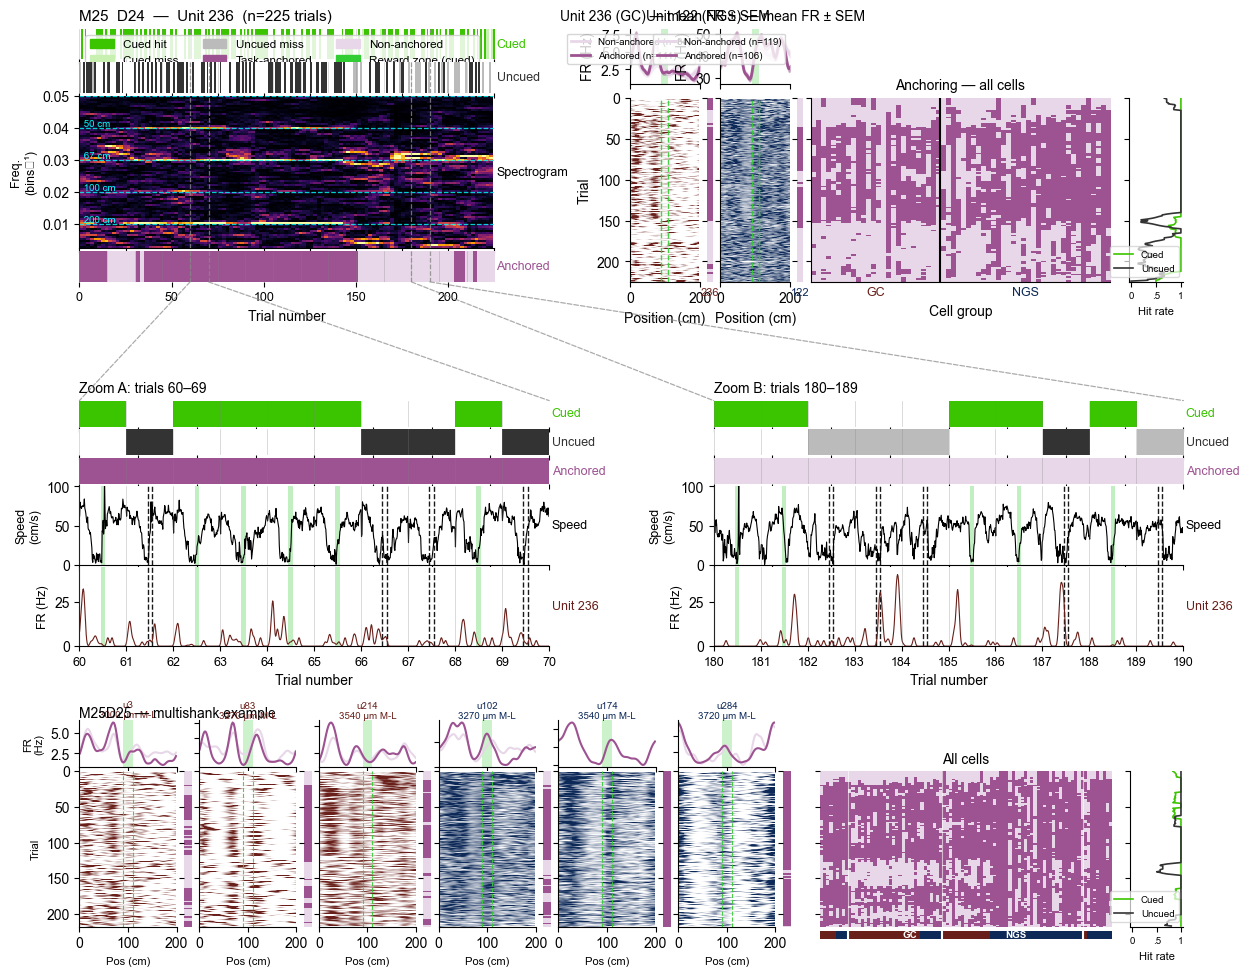

: 

In [ ]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches

# ═══════════════════════════════════════════════════════════════════════════════
EXAMPLE_MOUSE   = 25
EXAMPLE_DAY     = 24
EXAMPLE_CELL    = 236
EXAMPLE_CELL_2  = 122
ZOOM1_START     = 60;  ZOOM1_END  = 70
ZOOM2_START     = 180; ZOOM2_END  = 190

MS_MOUSE   = 25
MS_DAY     = 25
MS_GC_IDS  = [3, 83, 214]
MS_NGS_IDS = [102, 174, 284]
ROLL_WIN   = 15
# ═══════════════════════════════════════════════════════════════════════════════

COLOR_ANCHOR     = '#9d5391'
COLOR_NON_ANCHOR = '#e7d7e8'
gc_color         = gc_color_dark
ngs_color        = ngs_color_dark
COLOR_B_HIT      = '#3bc500'
COLOR_B_MISS     = '#c8f0b0'
COLOR_NB_HIT     = '#333333'
COLOR_NB_MISS    = '#bbbbbb'
COLOR_SPEED      = 'black'
COLOR_ZOOM_GUIDE = '#888888'
COLOR_RZ         = 'limegreen'

# ── Load M25D24 ───────────────────────────────────────────────────────────────
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    EXAMPLE_MOUSE, EXAMPLE_DAY, apply_zscore=False, apply_guassian_filter=False
)
rz_start = 90.0;  rz_end = 110.0;  bpt = int(tl / bs)

tc1 = gaussian_filter(np.nan_to_num(tcs[EXAMPLE_CELL]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
res1        = spectral_analysis({EXAMPLE_CELL: tc1, 1000: tc1}, tl, bs=bs)
S_cell1     = res1[3][0];  t_spec = res1[4];  fvalid = res1[5];  t_dist_spec = t_spec * bs

target_freqs  = np.arange(1, 6) * bs / tl
GRID_FREQ_IDX = [int(np.argmin(np.abs(fvalid - f))) for f in target_freqs]
grid_freqs    = fvalid[GRID_FREQ_IDX]

S_avg1     = res1[3].mean(0)
lbl_idx1   = np.isin(np.argmax(S_avg1, axis=0), GRID_FREQ_IDX).astype(int)
labels_ta1 = get_kmeans_spatial_labels(tc1, lbl_idx1, bs=bs, tl=tl)
n_trials1  = min(len(labels_ta1), len(tc1) // bpt)
labels_ta1 = labels_ta1[:n_trials1];  tc_2d1 = tc1[:n_trials1 * bpt].reshape(n_trials1, bpt)

tc2 = gaussian_filter(np.nan_to_num(tcs[EXAMPLE_CELL_2]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
res2       = spectral_analysis({EXAMPLE_CELL_2: tc2, 1000: tc2}, tl, bs=bs)
fvalid2    = res2[5];  GFI2 = [int(np.argmin(np.abs(fvalid2 - f))) for f in target_freqs]
S_avg2     = res2[3].mean(0)
lbl_idx2   = np.isin(np.argmax(S_avg2, axis=0), GFI2).astype(int)
labels_ta2 = get_kmeans_spatial_labels(tc2, lbl_idx2, bs=bs, tl=tl)
n_trials2  = min(len(labels_ta2), len(tc2) // bpt)
labels_ta2 = labels_ta2[:n_trials2];  tc_2d2 = tc2[:n_trials2 * bpt].reshape(n_trials2, bpt)

n_trials   = min(n_trials1, n_trials2)
labels_ta1 = labels_ta1[:n_trials];  tc_2d1 = tc_2d1[:n_trials]
labels_ta2 = labels_ta2[:n_trials];  tc_2d2 = tc_2d2[:n_trials]

nb_hit_mask  = make_hit_mask(beh, 'nb');  b_hit_mask  = make_hit_mask(beh, 'b')
nb_type_mask = make_trialtype_mask(beh, 'nb');  b_type_mask = make_trialtype_mask(beh, 'b')
trial_num_arr = np.array(beh['trial_number'])
pos_arr       = np.array(beh['P']);  speed_arr = np.array(beh['S'])
pos_bins      = np.linspace(0, tl, bpt + 1)

speed_2d = np.full((n_trials, bpt), np.nan)
for t in range(n_trials):
    m = trial_num_arr == (t + 1)
    if not m.any(): continue
    bsums, _ = np.histogram(pos_arr[m], bins=pos_bins, weights=speed_arr[m])
    bcnt,  _ = np.histogram(pos_arr[m], bins=pos_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        speed_2d[t] = np.where(bcnt > 0, bsums / bcnt, np.nan)

def _make_hit_display(hit_mask, type_mask, n):
    arr = np.zeros(n, dtype=float)
    nt  = min(len(type_mask), len(hit_mask), n)
    arr[:nt] = np.where(type_mask[:nt], np.where(hit_mask[:nt], 2.0, 1.0), 0.0)
    return arr

b_display       = _make_hit_display(b_hit_mask,  b_type_mask,  n_trials)
nb_display      = _make_hit_display(nb_hit_mask, nb_type_mask, n_trials)
anchor_display1 = np.where(np.isnan(labels_ta1.astype(float)), 2.0, labels_ta1.astype(float))
anchor_display2 = np.where(np.isnan(labels_ta2.astype(float)), 2.0, labels_ta2.astype(float))

dist_total   = n_trials * tl
z0_1, z1_1   = max(0, ZOOM1_START), min(n_trials, ZOOM1_END)
z0_2, z1_2   = max(0, ZOOM2_START), min(n_trials, ZOOM2_END)
dist_start_1, dist_end_1 = z0_1 * tl, z1_1 * tl
dist_start_2, dist_end_2 = z0_2 * tl, z1_2 * tl

def _rolling_hit_rate(hit_mask, type_mask, n, window=15):
    nt   = min(len(hit_mask), len(type_mask), n)
    rate = np.full(n, np.nan)
    for t in range(nt):
        w0, w1     = max(0, t - window // 2), min(nt, t + window // 2 + 1)
        is_type    = np.array(type_mask[w0:w1], dtype=bool)
        is_hit_typ = np.array(hit_mask[w0:w1],  dtype=bool) & is_type
        if is_type.sum() > 0:
            rate[t] = is_hit_typ.sum() / is_type.sum()
    return rate

b_hr_24  = _rolling_hit_rate(b_hit_mask,  b_type_mask,  n_trials, ROLL_WIN)
nb_hr_24 = _rolling_hit_rate(nb_hit_mask, nb_type_mask, n_trials, ROLL_WIN)

gcs_df, ngs_df, _ = classify_cells_both_sessions(
    mouse=EXAMPLE_MOUSE, day=EXAMPLE_DAY, percentile_threshold=95, verbose=False
)
gc_ids  = gcs_df.sort_values('grid_score', ascending=False)['cluster_id'].values.tolist()
ngs_ids = ngs_df.sort_values('cluster_id')['cluster_id'].values.tolist()
all_ids = [cid for cid in gc_ids + ngs_ids if cid in tcs]
n_gc    = sum(1 for cid in gc_ids if cid in tcs);  n_cells = len(all_ids)

tc_dict   = {cid: gaussian_filter(np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
             for cid in all_ids}
res_batch = spectral_analysis(tc_dict, tl, bs=bs)
Sxs_batch = res_batch[3];  fvalid_b = res_batch[5]
gfi_b     = [int(np.argmin(np.abs(fvalid_b - f))) for f in target_freqs]

raster_arr = np.full((n_cells, n_trials), 2.0)
for i, cid in enumerate(all_ids):
    tc_c  = tc_dict[cid]
    li_c  = np.isin(np.argmax(Sxs_batch[i], axis=0), gfi_b).astype(int)
    lab_c = get_kmeans_spatial_labels(tc_c, li_c, bs=bs, tl=tl)
    nt_c  = min(len(lab_c), len(tc_c) // bpt, n_trials)
    raster_arr[i, :nt_c] = np.where(np.isnan(lab_c[:nt_c].astype(float)), 2.0, lab_c[:nt_c].astype(float))

# ══════════════════════════════════════════════════════════════════════════════
# ── Load M25D25 ───────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
tcs_ms, _, _, last_ephys_bin_ms, beh_ms, _ = compute_vr_tcs(
    MS_MOUSE, MS_DAY, apply_zscore=False, apply_guassian_filter=False
)
gcs_ms_df, ngs_ms_df, _ = classify_cells_both_sessions(
    mouse=MS_MOUSE, day=MS_DAY, percentile_threshold=95, verbose=False
)

nb_hit_mask_ms  = make_hit_mask(beh_ms, 'nb');  b_hit_mask_ms  = make_hit_mask(beh_ms, 'b')
nb_type_mask_ms = make_trialtype_mask(beh_ms, 'nb');  b_type_mask_ms = make_trialtype_mask(beh_ms, 'b')

gcs_ms_recon = reconstruct_shank_id(gcs_ms_df.copy(), MS_MOUSE, colname='probe_x')
ngs_ms_recon = reconstruct_shank_id(ngs_ms_df.copy(), MS_MOUSE, colname='probe_x')

# ── Change 2: prefer SC_x with abs() for M-L position ────────────────────────
def _px_map(df):
    if 'SC_x' in df.columns:
        return df.set_index('cluster_id')['SC_x'].abs().to_dict()
    elif 'probe_x' in df.columns:
        return df.set_index('cluster_id')['probe_x'].to_dict()
    return {}

gc_px_map  = _px_map(gcs_ms_recon)
ngs_px_map = _px_map(ngs_ms_recon)
gc_shank_map  = gcs_ms_recon.set_index('cluster_id')['shank_id'].to_dict()
ngs_shank_map = ngs_ms_recon.set_index('cluster_id')['shank_id'].to_dict()

# Example cells: GC first (sorted by shank), then NGS (sorted by shank)
ex_info = (
    [{'cluster_id': c, 'cell_type': 'GC',  'shank_id': gc_shank_map.get(c, 0),
      'probe_x': gc_px_map.get(c, np.nan),  'color': gc_color}  for c in MS_GC_IDS] +
    [{'cluster_id': c, 'cell_type': 'NGS', 'shank_id': ngs_shank_map.get(c, 0),
      'probe_x': ngs_px_map.get(c, np.nan), 'color': ngs_color} for c in MS_NGS_IDS]
)
ex_info.sort(key=lambda x: (0 if x['cell_type'] == 'GC' else 1, x['shank_id']))

ms_ordered = [c['cluster_id'] for c in ex_info]
ms_colors  = [c['color']      for c in ex_info]
n_ms_cells = len(ms_ordered)

ms_tc_ex     = {}
ms_labels_ex = {}
for cid in ms_ordered:
    tc_c = gaussian_filter(np.nan_to_num(tcs_ms[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin_ms]
    ms_tc_ex[cid] = tc_c
    res_c = spectral_analysis({cid: tc_c, 1000: tc_c}, tl, bs=bs)
    fv_c  = res_c[5]
    gfi_c = [int(np.argmin(np.abs(fv_c - f))) for f in target_freqs]
    li_c  = np.isin(np.argmax(res_c[3].mean(0), axis=0), gfi_c).astype(int)
    ms_labels_ex[cid] = get_kmeans_spatial_labels(tc_c, li_c, bs=bs, tl=tl)

n_trials_ms_ex = min(
    min(len(ms_labels_ex[c]) for c in ms_ordered),
    min(len(ms_tc_ex[c]) // bpt for c in ms_ordered)
)
ms_tc_2d_ex = {}
for cid in ms_ordered:
    ms_labels_ex[cid] = ms_labels_ex[cid][:n_trials_ms_ex]
    ms_tc_2d_ex[cid]  = ms_tc_ex[cid][:n_trials_ms_ex * bpt].reshape(n_trials_ms_ex, bpt)

# All-cells raster (probe_x order)
cell_info_ms = []
for _, r in gcs_ms_recon.iterrows():
    if r['cluster_id'] in tcs_ms:
        cell_info_ms.append({'cluster_id': r['cluster_id'], 'cell_type': 'GC',
                              'shank_id': int(r.get('shank_id', 0))})
for _, r in ngs_ms_recon.iterrows():
    if r['cluster_id'] in tcs_ms:
        cell_info_ms.append({'cluster_id': r['cluster_id'], 'cell_type': 'NGS',
                              'shank_id': int(r.get('shank_id', 0))})
cell_info_ms.sort(key=lambda x: (x['shank_id'], 0 if x['cell_type'] == 'GC' else 1))

all_ids_ms    = [c['cluster_id'] for c in cell_info_ms]
cell_types_ms = [c['cell_type'] for c in cell_info_ms]
shank_ids_ms  = [c['shank_id']  for c in cell_info_ms]

tc_dict_ms = {cid: gaussian_filter(np.nan_to_num(tcs_ms[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin_ms]
              for cid in all_ids_ms}
res_ms    = spectral_analysis(tc_dict_ms, tl, bs=bs)
Sxs_ms    = res_ms[3];  fvalid_ms = res_ms[5]
gfi_ms    = [int(np.argmin(np.abs(fvalid_ms - f))) for f in target_freqs]

ms_rlab   = {};  nt_ms_lst = []
for i, cid in enumerate(all_ids_ms):
    tc_c  = tc_dict_ms[cid]
    li_c  = np.isin(np.argmax(Sxs_ms[i], axis=0), gfi_ms).astype(int)
    lab_c = get_kmeans_spatial_labels(tc_c, li_c, bs=bs, tl=tl)
    ms_rlab[cid] = lab_c
    nt_ms_lst.append(min(len(lab_c), len(tc_c) // bpt))

n_trials_ms     = min(nt_ms_lst)
n_trials_ms_row = min(n_trials_ms_ex, n_trials_ms)

raster_ms = np.full((len(all_ids_ms), n_trials_ms_row), 2.0)
for i, cid in enumerate(all_ids_ms):
    lab_c = ms_rlab[cid];  nt_c = min(len(lab_c), n_trials_ms_row)
    raster_ms[i, :nt_c] = np.where(np.isnan(lab_c[:nt_c].astype(float)), 2.0, lab_c[:nt_c].astype(float))

b_hr_ms  = _rolling_hit_rate(b_hit_mask_ms,  b_type_mask_ms,  n_trials_ms_row, ROLL_WIN)
nb_hr_ms = _rolling_hit_rate(nb_hit_mask_ms, nb_type_mask_ms, n_trials_ms_row, ROLL_WIN)

# ── Colour maps ───────────────────────────────────────────────────────────────
b_cmap      = ListedColormap(['white', COLOR_B_MISS,     COLOR_B_HIT])
nb_cmap     = ListedColormap(['white', COLOR_NB_MISS,    COLOR_NB_HIT])
hit_norm    = BoundaryNorm([0, 0.5, 1.5, 2.5], 3)
anchor_cmap = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
anchor_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)
type_cmap   = ListedColormap([gc_color, ngs_color])
type_norm   = BoundaryNorm([-0.5, 0.5, 1.5], 2)

# ── Layout ────────────────────────────────────────────────────────────────────
STRIP = 0.4;  SPEC = 2.0;  LINE = 1.2
H_FULL = [STRIP, STRIP, SPEC, STRIP]
H_ZOOM = [STRIP, STRIP, STRIP, LINE, LINE]

fig = plt.figure(figsize=(12, 10))

# gs_master: 2 rows — top panel | (zoom + MS combined)
gs_master = mgridspec.GridSpec(
    2, 1, figure=fig,
    height_ratios=[sum(H_FULL), sum(H_ZOOM) + sum(H_FULL)],
    hspace=0.30,
    left=0.05, right=0.97, top=0.95, bottom=0.04,
)

# gs_bottom: zoom row | MS row — with tight hspace between them
gs_bottom = mgridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_master[1],
    height_ratios=[sum(H_ZOOM), sum(H_FULL)],
    hspace=0.32,
)

gs_top = mgridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_master[0], width_ratios=[3, 4.0], wspace=0.28,
)
gs_right = mgridspec.GridSpecFromSubplotSpec(
    2, 7, subplot_spec=gs_top[1],
    height_ratios=[0.3, 1],
    width_ratios=[0.7, 0.06, 0.7, 0.06, 3.0, 0.04, 0.55],
    wspace=0.10, hspace=0.12,
)
ax_C1  = fig.add_subplot(gs_right[0, 0]);  ax_rm1 = fig.add_subplot(gs_right[1, 0])
ax_a1  = fig.add_subplot(gs_right[1, 1]);  ax_C2  = fig.add_subplot(gs_right[0, 2])
ax_rm2 = fig.add_subplot(gs_right[1, 2]);  ax_a2  = fig.add_subplot(gs_right[1, 3])
ax_R   = fig.add_subplot(gs_right[1, 4])
ax_hr_24 = fig.add_subplot(gs_right[1, 6], sharey=ax_R)
ax_C1.sharex(ax_rm1);  ax_C2.sharex(ax_rm2);  ax_rm1.sharex(ax_rm2)

gs_full  = mgridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs_top[0],  height_ratios=H_FULL, hspace=0.05)
gs_bot   = mgridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_bottom[0], width_ratios=[1, 1], wspace=0.35)
gs_zoom1 = mgridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_bot[0],  height_ratios=H_ZOOM, hspace=0.05)
gs_zoom2 = mgridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_bot[1],  height_ratios=H_ZOOM, hspace=0.05)

ax_F  = [fig.add_subplot(gs_full[i])  for i in range(4)]
ax_Z1 = [fig.add_subplot(gs_zoom1[i]) for i in range(5)]
ax_Z2 = [fig.add_subplot(gs_zoom2[i]) for i in range(5)]

# ── MS row: 3 sub-rows (avg_fr | rate_maps/raster | tiny_type_bar) ────────────
ms_col_widths   = [w for _ in range(n_ms_cells) for w in [1.0, 0.08]]
ms_extra_widths = [0.15, 3.0, 0.04, 0.55]
ms_all_widths   = ms_col_widths + ms_extra_widths
n_ms_cols       = len(ms_all_widths)
col_spacer      = 2 * n_ms_cells
col_raster      = 2 * n_ms_cells + 1
col_hr          = 2 * n_ms_cells + 3

# ── Change 1: match height_ratios [0.3, 1.0] from gs_right ───────────────────
gs_ms = mgridspec.GridSpecFromSubplotSpec(
    3, n_ms_cols, subplot_spec=gs_bottom[1],
    height_ratios=[0.3, 1.0, 0.05],   # avg FR | rate maps/raster | tiny type bar
    width_ratios=ms_all_widths,
    wspace=0.12, hspace=0.06,
)

ms_ax_avg  = []
ms_ax_rm   = []
ms_ax_anch = []
for i in range(n_ms_cells):
    cm, ca = 2 * i, 2 * i + 1
    ms_ax_avg.append(fig.add_subplot(gs_ms[0, cm]))
    ms_ax_rm.append(fig.add_subplot(gs_ms[1, cm]))
    ms_ax_anch.append(fig.add_subplot(gs_ms[1, ca]))
    ms_ax_avg[-1].sharex(ms_ax_rm[-1])

ax_R_ms  = fig.add_subplot(gs_ms[1, col_raster])
ax_hr_ms = fig.add_subplot(gs_ms[1, col_hr], sharey=ax_R_ms)
ax_cb_ms = fig.add_subplot(gs_ms[2, col_raster])   # type bar at BOTTOM


# ── Helpers ───────────────────────────────────────────────────────────────────
def _strip(ax, data, cmap, norm, d0, d1, tl, row_label, label_color='k'):
    t0, t1 = int(round(d0 / tl)), int(round(d1 / tl))
    arr = data[t0:t1]
    ax.imshow(arr[np.newaxis, :], aspect='auto', cmap=cmap, norm=norm,
              interpolation='nearest', extent=[d0, d1, 0.5, -0.5], origin='upper')
    ax.set_yticks([]);  ax.set_xlim(d0, d1)
    for s in ax.spines.values(): s.set_visible(False)
    ax.text(1.005, 0.5, row_label, transform=ax.transAxes,
            ha='left', va='center', fontsize=9, color=label_color)

def _spectrogram(ax, S, t_dist, fvalid, grid_freqs, d0, d1):
    dt = t_dist[1] - t_dist[0]
    win_mask = (t_dist >= d0 - dt) & (t_dist <= d1 + dt)
    if win_mask.sum() < 2: return
    t_sel = t_dist[win_mask];  S_sel = S[:, win_mask]
    vmax  = float(np.percentile(S_sel, 99))
    ax.imshow(S_sel, aspect='auto', origin='lower',
              extent=[t_sel[0], t_sel[-1], fvalid[0], fvalid[-1]],
              cmap='inferno', interpolation='nearest', vmin=0, vmax=vmax)
    for gf in grid_freqs:
        ax.axhline(gf, color='cyan', linewidth=0.9, linestyle='--', alpha=0.8)
        ax.text(d0 + (d1 - d0) * 0.005, gf, f' {bs/gf:.0f} cm',
                color='cyan', fontsize=7, va='bottom', clip_on=True)
    ax.set_ylabel('Freq.\n(bins⁻¹)', fontsize=9);  ax.set_xlim(d0, d1);  ax.set_ylim(fvalid[0], fvalid[-1])
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.text(1.005, 0.5, 'Spectrogram', transform=ax.transAxes, ha='left', va='center', fontsize=9)

def _vlines(axes, t_start, t_end, tl, d0, d1, every=1):
    for t in range(t_start, t_end + 1, every):
        for a in axes: a.axvline(t * tl, color='gray', linewidth=0.4, alpha=0.5, zorder=3)
    for a in axes: a.set_xlim(d0, d1)

def _trial_ticks(ax, tick_trials, tl):
    ax.set_xticks(tick_trials * tl)
    ax.set_xticklabels([str(t) for t in tick_trials], fontsize=9)
    ax.set_xlabel('Trial number', fontsize=10)

def _rz_marks(axes, z0, n_zoom, tl, rz_start, rz_end):
    for t_off in range(n_zoom):
        t_abs = z0 + t_off
        x0 = t_abs * tl + rz_start;  x1 = t_abs * tl + rz_end
        is_b  = (t_abs < len(b_type_mask))  and bool(b_type_mask[t_abs])
        is_nb = (t_abs < len(nb_type_mask)) and bool(nb_type_mask[t_abs])
        for a in axes:
            if is_b:
                a.axvspan(x0, x1, color=COLOR_RZ, alpha=0.3, zorder=1, linewidth=0)
            elif is_nb:
                a.axvline(x0, color='black', linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
                a.axvline(x1, color='black', linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)

def _draw_zoom(ax_Z, z0, z1, title):
    n_zoom = z1 - z0;  d0, d1 = z0 * tl, z1 * tl
    for a in ax_Z[:-1]: a.tick_params(labelbottom=False)
    _strip(ax_Z[0], b_display,       b_cmap,      hit_norm,    d0, d1, tl, 'Cued',     COLOR_B_HIT)
    _strip(ax_Z[1], nb_display,      nb_cmap,     hit_norm,    d0, d1, tl, 'Uncued',   COLOR_NB_HIT)
    _strip(ax_Z[2], anchor_display1, anchor_cmap, anchor_norm, d0, d1, tl, 'Anchored', COLOR_ANCHOR)
    ax_Z[0].set_title(title, fontsize=10, loc='left')
    ax_sp, ax_fr = ax_Z[3], ax_Z[4]
    x_dist = np.array([(z0 + t_off) * tl + (pos_i + 0.5) * bs
                        for t_off in range(n_zoom) for pos_i in range(bpt)])
    _rz_marks([ax_sp, ax_fr], z0, n_zoom, tl, rz_start, rz_end)
    ax_sp.plot(x_dist, speed_2d[z0:z1, :].ravel(), color=COLOR_SPEED, linewidth=0.8)
    ax_sp.set_ylabel('Speed\n(cm/s)', fontsize=9)
    ax_sp.text(1.005, 0.5, 'Speed', transform=ax_sp.transAxes,
               ha='left', va='center', fontsize=9, color=COLOR_SPEED)
    for s in ['top', 'right']: ax_sp.spines[s].set_visible(False)
    ax_fr.plot(x_dist, tc_2d1[z0:z1, :].ravel(), color=gc_color, linewidth=0.8)
    ax_fr.set_ylabel('FR (Hz)', fontsize=9);  ax_fr.set_ylim(bottom=0)
    ax_fr.text(1.005, 0.5, f'Unit {EXAMPLE_CELL}',
               transform=ax_fr.transAxes, ha='left', va='center', fontsize=9, color=gc_color)
    for s in ['top', 'right']: ax_fr.spines[s].set_visible(False)
    _vlines([ax_Z[0], ax_Z[1], ax_Z[2], ax_sp, ax_fr], z0, z1, tl, d0, d1)
    _trial_ticks(ax_fr, np.arange(z0, z1 + 1), tl)
    for a in ax_Z: a.set_xlim(d0, d1)
    return ax_sp, ax_fr

def _avg_fr_panel(ax, tc_2d, labels_ta, cell_id, color, title):
    x_pos = np.arange(bs / 2, tl + bs / 2, bs)
    ax.axvspan(rz_start, rz_end, color=COLOR_RZ, alpha=0.25, zorder=0, linewidth=0)
    for label_val, lcolor, lbl in [(0, COLOR_NON_ANCHOR, 'Non-anchored'), (1, COLOR_ANCHOR, 'Anchored')]:
        mask = labels_ta == label_val
        if mask.sum() > 5:
            avg_fr = np.nanmean(tc_2d[mask, :], axis=0)
            sem_fr = np.nanstd(tc_2d[mask, :], axis=0) / np.sqrt(mask.sum())
            ax.fill_between(x_pos, avg_fr - sem_fr, avg_fr + sem_fr, color=lcolor, alpha=0.35)
            ax.plot(x_pos, avg_fr, color=lcolor, linewidth=2, label=f'{lbl} (n={mask.sum()})')
    ax.tick_params(labelbottom=False);  ax.set_ylabel('FR (Hz)', fontsize=10)
    ax.set_title(title, fontsize=10);   ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, tl)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def _rate_map_panel(ax, tc, bpt, n_trials, color, xlabel=True):
    plot_firing_rate_map(ax, tc[:n_trials * bpt], bs=bs, tl=tl, p=95,
                         sort_indices=None, cmap=white_to_hex_cmap(color))
    ax.axvline(rz_start, color=COLOR_RZ, linewidth=1.0, linestyle='--', alpha=0.9)
    ax.axvline(rz_end,   color=COLOR_RZ, linewidth=1.0, linestyle='--', alpha=0.9)
    if xlabel: ax.set_xlabel('Position (cm)', fontsize=10)
    ax.set_xlim(0, tl)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def _anchor_strip(ax, anchor_display, n_trials, cell_id, cell_color):
    ax.imshow(anchor_display[:n_trials, np.newaxis], aspect='auto',
              cmap=anchor_cmap, norm=anchor_norm,
              extent=[-0.5, 0.5, n_trials, 0], interpolation='nearest', origin='upper')
    ax.set_xlim(-0.5, 0.5);  ax.set_xticks([]);  ax.tick_params(labelleft=False)
    ax.set_xlabel(f'{cell_id}', fontsize=8, color=cell_color)
    for s in ax.spines.values(): s.set_visible(False)

def _hit_rate_panel(ax, b_rate, nb_rate, n_trials):
    trials = np.arange(n_trials)
    ax.plot(b_rate[:n_trials],  trials, color=COLOR_B_HIT,  linewidth=1.2, label='Cued')
    ax.plot(nb_rate[:n_trials], trials, color=COLOR_NB_HIT, linewidth=1.2, label='Uncued')
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([0, 0.5, 1]);  ax.set_xticklabels(['0', '.5', '1'], fontsize=7)
    ax.tick_params(labelleft=False);  ax.set_xlabel('Hit rate', fontsize=8)
    ax.legend(fontsize=7, loc='lower right', framealpha=0.7)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)


# ── Full-session panel ────────────────────────────────────────────────────────
for a in ax_F[:-1]: a.tick_params(labelbottom=False)
_strip(ax_F[0], b_display,       b_cmap,      hit_norm,    0, dist_total, tl, 'Cued',     COLOR_B_HIT)
_strip(ax_F[1], nb_display,      nb_cmap,     hit_norm,    0, dist_total, tl, 'Uncued',   COLOR_NB_HIT)
_spectrogram(ax_F[2], S_cell1, t_dist_spec, fvalid, grid_freqs, 0, dist_total)
_strip(ax_F[3], anchor_display1, anchor_cmap, anchor_norm, 0, dist_total, tl, 'Anchored', COLOR_ANCHOR)
ax_F[0].set_title(f'M{EXAMPLE_MOUSE}  D{EXAMPLE_DAY}  —  Unit {EXAMPLE_CELL}  (n={n_trials} trials)',
                  fontsize=11, loc='left')
for dist_x in [dist_start_1, dist_end_1, dist_start_2, dist_end_2]:
    for a in ax_F:
        a.axvline(dist_x, color=COLOR_ZOOM_GUIDE, linestyle='--', linewidth=0.9, alpha=0.8, zorder=5)
every_n = max(5, n_trials // 15)
_vlines([ax_F[0], ax_F[1], ax_F[3]], 0, n_trials, tl, 0, dist_total, every=every_n)
_trial_ticks(ax_F[3], np.arange(0, n_trials + 1, 50), tl)
for a in ax_F: a.set_xlim(0, dist_total)

# ── Zoom panels ───────────────────────────────────────────────────────────────
ax_sp1, ax_fr1 = _draw_zoom(ax_Z1, z0_1, z1_1, f'Zoom A: trials {z0_1}–{z1_1-1}')
ax_sp2, ax_fr2 = _draw_zoom(ax_Z2, z0_2, z1_2, f'Zoom B: trials {z0_2}–{z1_2-1}')
for ax in [ax_sp1, ax_sp2]: ax.set_ylim(0, 100)
fr_max = max(np.nanmax(tc_2d1[z0_1:z1_1]), np.nanmax(tc_2d1[z0_2:z1_2]))
for ax in [ax_fr1, ax_fr2]: ax.set_ylim(0, fr_max * 1.1)

# ── Connecting lines ──────────────────────────────────────────────────────────
for (d_s, d_e), ax_Z in [((dist_start_1, dist_end_1), ax_Z1), ((dist_start_2, dist_end_2), ax_Z2)]:
    for xy_top, xy_bot in [((d_s / dist_total, 0.0), (0.0, 1.0)), ((d_e / dist_total, 0.0), (1.0, 1.0))]:
        fig.add_artist(ConnectionPatch(
            xyA=xy_top, coordsA='axes fraction', axesA=ax_F[3],
            xyB=xy_bot, coordsB='axes fraction', axesB=ax_Z[0],
            color=COLOR_ZOOM_GUIDE, linestyle='--', linewidth=0.9,
            alpha=0.7, clip_on=False, zorder=10,
        ))

# ── Cell 1 (GC) ──────────────────────────────────────────────────────────────
_avg_fr_panel(ax_C1, tc_2d1, labels_ta1, EXAMPLE_CELL, gc_color, f'Unit {EXAMPLE_CELL} (GC) — mean FR ± SEM')
_rate_map_panel(ax_rm1, tc1, bpt, n_trials, gc_color);  ax_rm1.set_ylabel('Trial', fontsize=10)
_anchor_strip(ax_a1, anchor_display1, n_trials, EXAMPLE_CELL, gc_color)

# ── Cell 2 (NGS) ─────────────────────────────────────────────────────────────
_avg_fr_panel(ax_C2, tc_2d2, labels_ta2, EXAMPLE_CELL_2, ngs_color, f'Unit {EXAMPLE_CELL_2} (NGS) — mean FR ± SEM')
_rate_map_panel(ax_rm2, tc2, bpt, n_trials, ngs_color);  ax_rm2.tick_params(labelleft=False)
_anchor_strip(ax_a2, anchor_display2, n_trials, EXAMPLE_CELL_2, ngs_color)

# ── All-cells raster M25D24 ───────────────────────────────────────────────────
ax_R.imshow(raster_arr.T, aspect='auto', cmap=anchor_cmap, norm=anchor_norm,
            extent=[-0.5, n_cells - 0.5, n_trials, 0], interpolation='nearest', origin='upper')
ax_R.axvline(n_gc - 0.5, color='black', linewidth=1.5)
ax_R.tick_params(labelleft=False)
ax_R.set_xlim(-0.5, n_cells - 0.5)
ax_R.set_xticks([n_gc / 2 - 0.5, n_gc + (n_cells - n_gc) / 2 - 0.5])
ax_R.set_xticklabels(['GC', 'NGS'], fontsize=9);  ax_R.tick_params(axis='x', length=0)
ax_R.xaxis.get_ticklabels()[0].set_color(gc_color);  ax_R.xaxis.get_ticklabels()[1].set_color(ngs_color)
ax_R.set_xlabel('Cell group', fontsize=10);  ax_R.set_title('Anchoring — all cells', fontsize=10)
for s in ['top', 'right']: ax_R.spines[s].set_visible(False)
_hit_rate_panel(ax_hr_24, b_hr_24, nb_hr_24, n_trials)
for ax in [ax_rm1, ax_a1, ax_rm2, ax_a2, ax_R, ax_hr_24]: ax.set_ylim(n_trials, 0)

# ══════════════════════════════════════════════════════════════════════════════
# ── MS row: example cells (GC first, then NGS) ───────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
x_pos_ms = np.arange(bs / 2, tl + bs / 2, bs)
ms_ax_avg[0].set_title(f'M{MS_MOUSE}D{MS_DAY} — multishank example', fontsize=10, loc='left')

for i, (ei, cid, color) in enumerate(zip(ex_info, ms_ordered, ms_colors)):
    ax_avg = ms_ax_avg[i];  ax_rm = ms_ax_rm[i];  ax_an = ms_ax_anch[i]
    lab    = ms_labels_ex[cid];  tc_2d = ms_tc_2d_ex[cid];  tc_1d = ms_tc_ex[cid]

    # Title with M-L position from abs(SC_x)
    px = ei['probe_x']
    px_str = f'\n{px:.0f} μm M-L' if not (isinstance(px, float) and np.isnan(px)) else ''
    ax_avg.set_title(f'u{cid}{px_str}', fontsize=7, color=color, pad=1)

    ax_avg.axvspan(rz_start, rz_end, color=COLOR_RZ, alpha=0.25, zorder=0, linewidth=0)
    for lv, lc in [(0, COLOR_NON_ANCHOR), (1, COLOR_ANCHOR)]:
        mask = lab == lv
        if mask.sum() > 5:
            avg_fr = np.nanmean(tc_2d[mask, :], axis=0)
            ax_avg.plot(x_pos_ms, avg_fr, color=lc, linewidth=1.5)
    ax_avg.tick_params(labelbottom=False);  ax_avg.set_xlim(0, tl)
    for s in ['top', 'right']: ax_avg.spines[s].set_visible(False)
    if i == 0: ax_avg.set_ylabel('FR\n(Hz)', fontsize=8)
    else:      ax_avg.tick_params(labelleft=False)

    plot_firing_rate_map(ax_rm, tc_1d[:n_trials_ms_row * bpt], bs=bs, tl=tl, p=95,
                         sort_indices=None, cmap=white_to_hex_cmap(color))
    ax_rm.axvline(rz_start, color=COLOR_RZ, linewidth=0.8, linestyle='--', alpha=0.9)
    ax_rm.axvline(rz_end,   color=COLOR_RZ, linewidth=0.8, linestyle='--', alpha=0.9)
    ax_rm.set_xlabel('Pos (cm)', fontsize=8);  ax_rm.set_xlim(0, tl)
    for s in ['top', 'right']: ax_rm.spines[s].set_visible(False)
    if i == 0: ax_rm.set_ylabel('Trial', fontsize=8)
    else:      ax_rm.tick_params(labelleft=False)

    ad = np.where(np.isnan(lab.astype(float)), 2.0, lab.astype(float))
    ax_an.imshow(ad[:n_trials_ms_row, np.newaxis], aspect='auto',
                 cmap=anchor_cmap, norm=anchor_norm,
                 extent=[-0.5, 0.5, n_trials_ms_row, 0], interpolation='nearest', origin='upper')
    ax_an.set_xlim(-0.5, 0.5);  ax_an.set_xticks([]);  ax_an.tick_params(labelleft=False)
    for s in ax_an.spines.values(): s.set_visible(False)

# ── All-cells raster M25D25 — spines off, no xlabel ──────────────────────────
n_all_ms = len(all_ids_ms)
ax_R_ms.imshow(raster_ms.T, aspect='auto', cmap=anchor_cmap, norm=anchor_norm,
               extent=[-0.5, n_all_ms - 0.5, n_trials_ms_row, 0],
               interpolation='nearest', origin='upper')
for j in range(1, n_all_ms):
    if shank_ids_ms[j] != shank_ids_ms[j - 1]:
        ax_R_ms.axvline(j - 0.5, color='white', linewidth=0.8, alpha=0.6)
ax_R_ms.tick_params(labelleft=False, labelbottom=False, bottom=False)
ax_R_ms.set_xlim(-0.5, n_all_ms - 0.5)
ax_R_ms.set_xticks([])
ax_R_ms.set_title('All cells', fontsize=10)
for s in ax_R_ms.spines.values(): s.set_visible(False)

# ── Type bar at BOTTOM of raster ──────────────────────────────────────────────
type_arr = np.array([0 if t == 'GC' else 1 for t in cell_types_ms])
ax_cb_ms.imshow(type_arr[np.newaxis, :], aspect='auto',
                cmap=type_cmap, norm=type_norm,
                extent=[-0.5, n_all_ms - 0.5, 0.5, -0.5],
                interpolation='nearest', origin='upper')
for j in range(1, n_all_ms):
    if shank_ids_ms[j] != shank_ids_ms[j - 1]:
        ax_cb_ms.axvline(j - 0.5, color='white', linewidth=1.5)
gc_x_mid  = float(np.mean(np.where(type_arr == 0)[0])) if (type_arr == 0).any() else 0
ngs_x_mid = float(np.mean(np.where(type_arr == 1)[0])) if (type_arr == 1).any() else n_all_ms - 1
ax_cb_ms.text(gc_x_mid,  0, 'GC',  ha='center', va='center', fontsize=7, color='white', fontweight='bold')
ax_cb_ms.text(ngs_x_mid, 0, 'NGS', ha='center', va='center', fontsize=7, color='white', fontweight='bold')
ax_cb_ms.set_xlim(-0.5, n_all_ms - 0.5);  ax_cb_ms.set_ylim(0.5, -0.5)
ax_cb_ms.set_xticks([]);  ax_cb_ms.set_yticks([])
for s in ax_cb_ms.spines.values(): s.set_visible(False)

_hit_rate_panel(ax_hr_ms, b_hr_ms, nb_hr_ms, n_trials_ms_row)
for ax in ms_ax_rm + ms_ax_anch + [ax_R_ms, ax_hr_ms]: ax.set_ylim(n_trials_ms_row, 0)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=COLOR_B_HIT,      label='Cued hit'),
    mpatches.Patch(color=COLOR_B_MISS,     label='Cued miss'),
    mpatches.Patch(color=COLOR_NB_HIT,     label='Uncued hit'),
    mpatches.Patch(color=COLOR_NB_MISS,    label='Uncued miss'),
    mpatches.Patch(color=COLOR_ANCHOR,     label='Task-anchored'),
    mpatches.Patch(color=COLOR_NON_ANCHOR, label='Non-anchored'),
    mpatches.Patch(color=COLOR_RZ,         label='Reward zone (cued)'),
]
ax_F[0].legend(handles=legend_patches, fontsize=8.5, loc='upper left', ncol=3, framealpha=0.85)

plt.savefig(
    f'M{EXAMPLE_MOUSE}D{EXAMPLE_DAY}_unit{EXAMPLE_CELL}_spectrogram_overview_with_multishank.pdf',
    dpi=300, bbox_inches='tight'
)
plt.show()


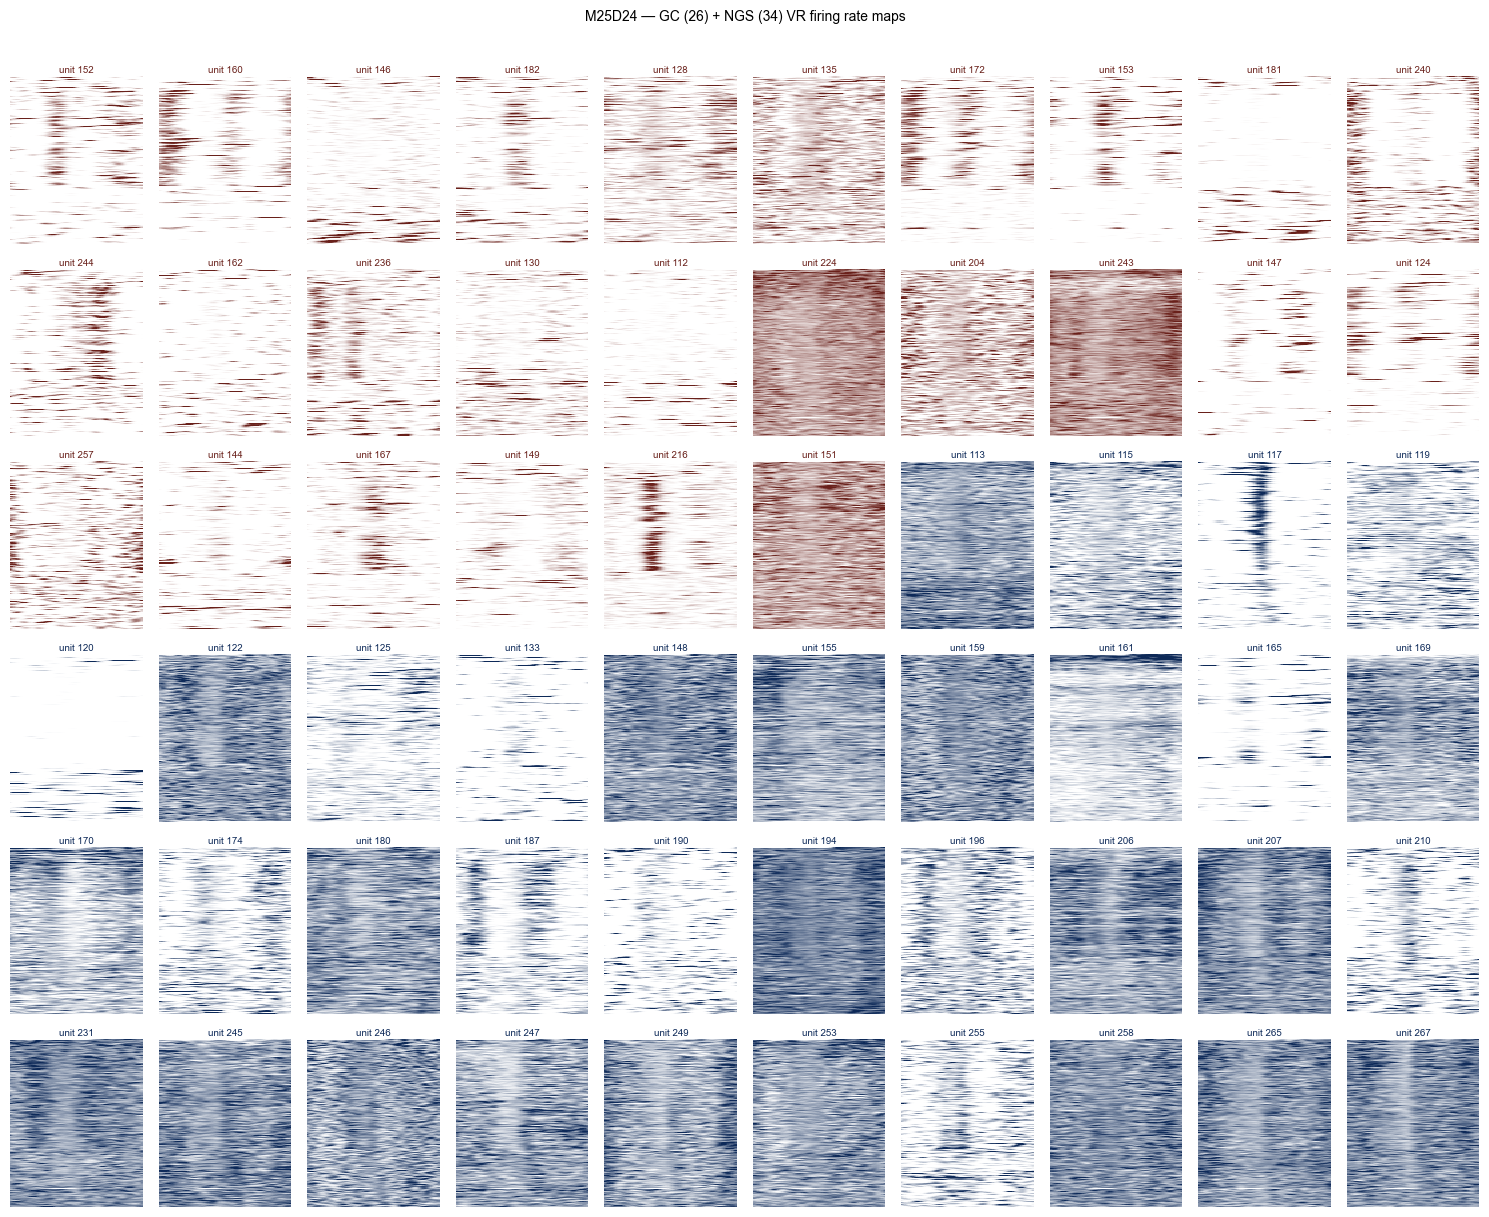

In [73]:
mouse, day = 25, 24  # example session

# Classify GC and NGS cells
gcs, ngs, _ = classify_cells_both_sessions(
    mouse=mouse, day=day, percentile_threshold=95, verbose=False
)
gcs = gcs.sort_values('grid_score', ascending=False)
ngs = ngs.sort_values('cluster_id')

gc_ids  = gcs['cluster_id'].values.tolist()
ngs_ids = ngs['cluster_id'].values.tolist()
all_ids    = gc_ids + ngs_ids
all_colors = [gc_color_dark] * len(gc_ids) + [ngs_color_dark] * len(ngs_ids)

# Compute VR tuning curves
tcs, _, _, last_ephys_bin, _, _ = compute_vr_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=True
)
max_len = last_ephys_bin // (tl // bs)

# Plot
ncols = 10
nrows = int(np.ceil(len(all_ids) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(ncols * 1.5, nrows * 2.0))
axes = np.array(axes).reshape(nrows, ncols)

for idx, (cid, color) in enumerate(zip(all_ids, all_colors)):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    if cid in tcs:
        tc = tcs[cid][:int(max_len * (tl // bs))]
        plot_firing_rate_map(ax, tc, bs, tl, cmap=white_to_hex_cmap(color))
    ax.set_title(f'unit {cid}', color=color, fontsize=7, pad=2)
    ax.axis('off')

for idx in range(len(all_ids), nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].axis('off')

plt.suptitle(f'M{mouse}D{day} — GC ({len(gc_ids)}) + NGS ({len(ngs_ids)}) VR firing rate maps',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


## GC firing reconstruction from NGS cells — per-shank XGBoost decoding

### What is shown

Each row is one target **grid cell (GC)**. For that cell we show five panels left to right:

| Panel | Description |
|-------|-------------|
| **True** | Observed VR firing rate map (trials × position). The colour strip below each map shows the trial-by-trial **task-anchored label**: purple = anchored (firing is spatially periodic and phase-locked to the task structure), pink = non-anchored. |
| **sh1 – sh4** | Reconstructed firing rate map, one per shank. Each reconstruction uses only the **NGS (non-grid spatial) cells recorded on that shank** as covariates. |

The average position-tuning profile (split by anchored/non-anchored trials) is shown above each rate map.

---

### Reconstruction pipeline

For each target GC and each shank:

1. **Features** — time-binned firing rates (`tcs_time`, 10 ms bins) of all NGS cells on the shank, concatenated with instantaneous position-in-track (`pos_in_time`).
2. **XGBoost cross-validation** — `MLencoding(tunemodel='xgboost', cov_history=True, ...)` is fit with `fit_cv(..., continuous_folds=True)`, yielding a predicted firing-rate time series $\hat{y}(t)$ and a per-fold pseudo-R² (`pR²`).
3. **Rate-map recovery** — $\hat{y}(t)$ is passed to `compute_vr_tcs_using_expected_spikes`, which Poisson-samples synthetic spikes and bins them into a position × trial map, giving the reconstructed tuning curve `tc_pred`.
4. **Task-anchored labels** — the same spectral + k-means pipeline used on the true TC is applied to `tc_pred` to assign an anchored/non-anchored label to each trial.

---

### Accuracy metrics

For each reconstruction panel the title reports three numbers:

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **pR²** | $1 - \frac{\text{MSE}(\hat{y}, y)}{\text{Var}(y)}$ (mean across CV folds) | How well the XGBoost model predicts the GC time series from NGS activity + position. |
| **acc** | $\frac{1}{N}\sum_{t=1}^{N} \mathbf{1}[\hat{l}_t = l_t]$ | Fraction of trials where the reconstructed task-anchored label matches the true label. |
| **Δacc** | $\text{acc} - \text{chance}$ | Accuracy **above the majority-class baseline**. |

#### Chance level

The chance baseline is the accuracy a **majority-vote classifier** would achieve — i.e. always predict whichever label (anchored or non-anchored) occurs more often in the true labels:

$$\text{chance} = \max\bigl(p_\text{anch},\ 1 - p_\text{anch}\bigr) \times 100\%$$

where $p_\text{anch}$ is the proportion of anchored trials. A session that is 70 % anchored has a chance level of 70 %; a balanced session has a chance level of 50 %.

A **positive Δacc** means the reconstruction recovers task-anchoring structure beyond what is predictable from the base rate alone. A Δacc near zero means the predicted labels carry no information about true anchoring above chance.


In [78]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

ngs_color = ngs_color_dark
gc_color  = "#90312a"

mouse, day = 26, 19
cluster_ids    = [24, 201, 352, 430]
cluster_labels = [f'unit {cid}' for cid in cluster_ids]
cluster_colors = [gc_color] * len(cluster_ids)

xgb_history = MLencoding(
    tunemodel='xgboost',
    cov_history=True, spike_history=False,
    window=time_bs, n_filters=5, max_time=1000,
)

# ── Load data ─────────────────────────────────────────────────────────────────
gcs, ngs, all_cells = classify_cells_both_sessions(
    mouse=mouse, day=day, percentile_threshold=95, verbose=False
)
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False,
    source_path=source_path,
)
last_ephys_time_bin = clusters[clusters.index[0]].count(
    bin_size=time_bs, time_units='ms'
).index[-1]
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

dt_in_time  = np.array(
    beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
    - ((beh['trial_number'][0] - 1) * tl)
)
pos_in_time = dt_in_time % tl
if np.any(np.isnan(pos_in_time)):
    pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl

gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
gc_shank_ids  = sorted(gcs['shank_id'].unique())
ngs_shank_ids = sorted(ngs['shank_id'].unique())
all_shank_ids = sorted(set(gc_shank_ids) | set(ngs_shank_ids))

bpt          = int(tl / bs)
n_trials_tot = last_ephys_bin // bpt

_gc_ids  = set(gcs['cluster_id'].astype(int))
_ngs_ids = set(ngs['cluster_id'].astype(int))
ns_id    = int(
    all_cells[~all_cells['cluster_id'].isin(_gc_ids | _ngs_ids)]['cluster_id'].values[0]
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def _labels_from_tc(tc, cid):
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin]
    results   = spectral_analysis({cid: tc, 1000: tc}, tl, bs=bs)
    S         = results[3].mean(0)
    max_peaks = np.argmax(S, axis=0)
    label_idx = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
    labels    = get_kmeans_spatial_labels(tc, label_idx, bs=bs, tl=tl)
    return tc, labels


def _accuracy_vs_chance(labels_true, labels_pred):
    """Return (acc, chance, delta) as percentages. Chance = majority-class baseline."""
    valid   = ~(np.isnan(labels_true.astype(float)) | np.isnan(labels_pred.astype(float)))
    if valid.sum() == 0:
        return np.nan, np.nan, np.nan
    lt, lp  = labels_true[valid], labels_pred[valid]
    acc     = np.mean(lt == lp) * 100
    p_anch  = np.mean(lt == 1)
    chance  = max(p_anch, 1 - p_anch) * 100
    return acc, chance, acc - chance


def _reconstruct_xgb(target_cid, ngs_cids):
    target_fr = np.asarray(tcs_time[target_cid])
    T         = len(target_fr)
    pos       = pos_in_time[:T]
    ngs_avail = [c for c in ngs_cids if c in tcs_time]
    if not ngs_avail:
        return None, np.nan
    ngs_mat = np.vstack([
        np.pad(np.asarray(tcs_time[c])[:T],
               (0, max(0, T - len(np.asarray(tcs_time[c])[:T]))),
               mode='constant')
        for c in ngs_avail
    ]).T
    Y_hat, pR2_cv = xgb_history.fit_cv(
        np.column_stack([pos, ngs_mat]), target_fr,
        verbose=0, continuous_folds=True,
    )
    pR2 = float(np.nanmean(pR2_cv))
    tcs_es, _, _, last_eb, _, _ = compute_vr_tcs_using_expected_spikes(
        mouse, day, apply_zscore=False, apply_guassian_filter=False,
        vr_type='VR', source_path=source_path, expected_spikes={ns_id: Y_hat},
    )
    tc_pred = gaussian_filter(
        np.nan_to_num(tcs_es[ns_id]).astype(np.float64), sigma=2.5
    )[:last_eb]
    return tc_pred, pR2


# ── Reconstruct each GC using NGS from each shank ────────────────────────────
reconstructed_tcs = {cid: {} for cid in cluster_ids}
pR2_values        = {cid: {} for cid in cluster_ids}

for cid in cluster_ids:
    if cid not in tcs_time:
        continue
    for shank in all_shank_ids:
        ngs_on_shank = ngs[ngs['shank_id'] == shank]['cluster_id'].values.tolist()
        print(f"unit {cid}  sh{shank+1}  ({len(ngs_on_shank)} NGS)...", end=' ')
        tc_pred, pR2 = _reconstruct_xgb(cid, ngs_on_shank)
        reconstructed_tcs[cid][shank] = tc_pred
        pR2_values[cid][shank]        = pR2
        print(f"pR²={pR2:.3f}")

# ── Figure ─────────────────────────────────────────────────────────────────────
cmap_ta = ListedColormap(["#e7d7e8", "#9d5391", "white"])
norm_ta = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap_ta.N)

n_cells       = len(cluster_ids)
n_panels      = 1 + len(all_shank_ids)   # true + 4 shank recons
# columns: [rate, scatter] × n_panels  (no population rasters)
width_ratios  = [1, 0.1] * n_panels
n_cols        = 2 * n_panels
height_ratios = [h for _ in range(n_cells) for h in (0.3, 1.0)]

fig = plt.figure(figsize=(rm_figsize[0] * 2.2 * n_panels, rm_figsize[1] * 1.5 * n_cells))
gs  = mgridspec.GridSpec(
    n_cells * 2, n_cols,
    height_ratios=height_ratios,
    width_ratios=width_ratios,
    figure=fig, wspace=0.3, hspace=0.15,
)

for i, (cid, cell_label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
    r_avg, r_rate = 2 * i, 2 * i + 1

    # Build panel list: (tc, labels, title)
    panels = []
    if cid in tcs:
        tc_true, labels_true = _labels_from_tc(tcs[cid], cid)
        panels.append((tc_true, labels_true, cell_label))
    else:
        tc_true, labels_true = None, None
        panels.append((None, None, cell_label))

    for shank in all_shank_ids:
        tc_pred = reconstructed_tcs[cid].get(shank)
        pR2     = pR2_values[cid].get(shank, np.nan)
        if tc_pred is not None and labels_true is not None:
            _, labels_pred       = _labels_from_tc(tc_pred, cid)
            acc, chance, delta   = _accuracy_vs_chance(labels_true, labels_pred)
            title = f'sh{shank+1}  pR²={pR2:.2f}\nacc={acc:.0f}%  Δ={delta:+.0f}% (ch={chance:.0f}%)'
            panels.append((tc_pred, labels_pred, title))
        else:
            panels.append((None, None, f'sh{shank+1}'))

    for p_idx, (tc_, labels_, title) in enumerate(panels):
        col_base = 2 * p_idx
        ax_avg   = fig.add_subplot(gs[r_avg,  col_base])
        ax_rate  = fig.add_subplot(gs[r_rate, col_base])
        ax_scat  = fig.add_subplot(gs[r_rate, col_base + 1])
        fig.add_subplot(gs[r_avg, col_base + 1]).axis('off')

        if tc_ is None:
            ax_avg.axis('off'); ax_rate.axis('off'); ax_scat.axis('off')
            ax_avg.set_title(title, fontsize=7, color=color)
            continue

        for lv, lc in zip([0, 1], ["#e7d7e8", "#9d5391"]):
            mask = labels_ == lv
            if mask.sum() > 5:
                x, y = get_avg_profile(tc_, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=lc, linewidth=2)
        ax_avg.set_title(title, fontsize=7, color=color)
        ax_avg.set_xticks([])

        plot_firing_rate_map(ax_rate, tc_, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
        ax_rate.imshow(np.expand_dims(labels_, axis=0), aspect='auto',
                       cmap=cmap_ta, norm=norm_ta, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15*(ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')

        for lv, lc in zip([0, 1], ["#e7d7e8", "#9d5391"]):
            mask = labels_ == lv
            ax_scat.scatter(np.zeros(mask.sum()), np.where(mask)[0],
                            color=lc, rasterized=True, s=5, marker='_')
        ax_scat.axis('off')
        ax_scat.set_ylim(0, len(labels_)); ax_scat.invert_yaxis()

        if i == 0 and p_idx == 0:
            ax_avg.set_ylabel('FR (Hz)')
            ax_rate.set_ylabel('Trial')

plt.subplots_adjust(wspace=0.3, hspace=0.15, bottom=0.1)
plt.savefig(f'M{mouse}D{day}_gc_xgb_recon_4shanks.pdf')
plt.show()


KeyboardInterrupt: 